### 1. Install Dependencies

In [1]:
!python -m pip install -q timm pandas matplotlib kaggle scikit-learn wandb grad-cam seaborn albumentations


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


### 2. Imports

In [2]:
import os
import gc
import re
import time
import math
import random
import warnings
from dataclasses import dataclass
from pathlib import Path
from tqdm.auto import tqdm
import json
import shutil
import zipfile
import subprocess
from datetime import datetime
import seaborn as sns
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import wandb
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
os.environ["PYTHONHASHSEED"] = "42"
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode, RandomResizedCrop
from torch.optim.lr_scheduler import _LRScheduler, CosineAnnealingLR
import timm
import cv2
import albumentations as A
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

warnings.filterwarnings("ignore")

/opt/venv/lib/python3.10/site-packages/apex/transformer/functional/fused_rope.py:49: UserWarning: Aiter backend is selected for fused RoPE. This has lower precision. To disable aiter, export USE_ROCM_AITER_ROPE_BACKEND=0
  warnings.warn("Aiter backend is selected for fused RoPE. This has lower precision. To disable aiter, export USE_ROCM_AITER_ROPE_BACKEND=0", UserWarning)


### 3. Experiment Config & Paths

In [3]:
# EXPERIMENT ID
EXPERIMENT_CODE = "E05"
SEED = 42

# REPRODUCIBILITY
DETERMINISTIC = True
DETERMINISTIC_WARN_ONLY = True
DISABLE_TF32 = True

# MODEL IDENTIFICATION
IS_KAGGLE = False
IS_VIDEOMAE_NOTEBOOK = "VideoMAEForVideoClassification" in globals()

MODEL_KIND = (
    "spatiotemporal_videomae"
    if IS_VIDEOMAE_NOTEBOOK
    else "spatial_vit"
)

# FIXED WORKSPACE PATH
WORKSPACE_ROOT = Path("/workspace").resolve()
RUNTIME_ROOT = WORKSPACE_ROOT / "wdf46f_runtime"
DATASET_ROOT = RUNTIME_ROOT / "wilddeepfake-46f"
INDEX_ROOT = Path("/shared-docker")

# Folder output eksperimen.
OUTPUT_ROOT = WORKSPACE_ROOT / "experiments" / MODEL_KIND
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# MODEL PATH
MODEL_NAME = "vit_base_patch16_224.mae"

# Hanya digunakan oleh notebook spasiotemporal VideoMAE.
MODEL_ROOT = RUNTIME_ROOT / "kaggle_models"
MODEL_CHECKPOINT = MODEL_ROOT / "videomae-base-finetuned-ssv2"

# DEVICE DAN AMP
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IS_ROCM = torch.version.hip is not None
USE_AMP = DEVICE.type == "cuda"
AMP_DTYPE = torch.bfloat16 if IS_ROCM else torch.float16
USE_GRAD_SCALER = USE_AMP and AMP_DTYPE == torch.float16

# LABEL
CLASS_TO_IDX = {"real": 0, "fake": 1}
IDX_TO_CLASS = {0: "real", 1: "fake"}

# HYPERPARAMETER
BATCH_SIZE_CLIPS = 32
EPOCHS = 25
LR = 5e-5
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 8

USE_EARLY_STOPPING = False
EARLY_STOPPING_PATIENCE = 4

# SCHEDULER
# - "LinearDecayLR"
# - "CosineAnnealingLR"
SCHEDULER_NAME = "CosineAnnealingLR"

# LinearDecayLR
SCHEDULER_START_DECAY = EPOCHS // 4
SCHEDULER_BOOSTER = 2

# CosineAnnealingLR
SCHEDULER_T_MAX = EPOCHS
SCHEDULER_ETA_MIN = 0.0

# DROPOUT
DROPOUT_RATE = 0.0
ATTENTION_DROPOUT_RATE = 0.0
DROP_PATH_RATE = 0.0

# DATASET FILE EXTENSION
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}

# Geometry augmentation
AUG_GEOMETRY_ONEOF_PROB = 0.5
AUG_PROB_HFLIP = 0.5

AUG_CROP_LIMIT = 0.15
AUG_CROP_PROB = 0.5

AUG_SCALE_LIMIT = 0.15
AUG_SCALE_PROB = 0.5

# Color / degradation augmentation
AUG_COLORJITTER_PROB = 0.3
AUG_COLORJITTER_BRIGHTNESS = 0.2
AUG_COLORJITTER_CONTRAST = 0.2
AUG_COLORJITTER_SATURATION = 0.2
AUG_COLORJITTER_HUE = 0.2

AUG_BLUR_OR_NOISE_ONEOF_PROB = 0.5

AUG_GAUSSIAN_BLUR_PROB = 0.3
AUG_GAUSSIAN_BLUR_LIMIT = (3, 7)

AUG_GAUSSNOISE_PROB = 0.3
AUG_GAUSSNOISE_VAR_LIMIT = (10.0, 50.0)

# LOSS
USE_FOCAL_LOSS = False
FOCAL_GAMMA = 2.0
USE_FOCAL_ALPHA = True

# NORMALISASI
NORM_MEAN = (0.485, 0.456, 0.406)
NORM_STD = (0.229, 0.224, 0.225)

# CONFIG SUMMARY
print("MODEL_KIND             :", MODEL_KIND)
print("WORKSPACE_ROOT         :", WORKSPACE_ROOT)
print("RUNTIME_ROOT           :", RUNTIME_ROOT)
print("DATASET_ROOT           :", DATASET_ROOT)
print("INDEX_ROOT             :", INDEX_ROOT)
print("MODEL_ROOT             :", MODEL_ROOT)
print("MODEL_CHECKPOINT       :", MODEL_CHECKPOINT)
print("OUTPUT_ROOT            :", OUTPUT_ROOT)

print("\nEXPERIMENT_CODE        :", EXPERIMENT_CODE)
print("BATCH_SIZE_CLIPS       :", BATCH_SIZE_CLIPS)
print("EPOCHS                 :", EPOCHS)
print("LR                     :", LR)
print("WEIGHT_DECAY           :", WEIGHT_DECAY)
print("SCHEDULER_NAME         :", SCHEDULER_NAME)
print("USE_FOCAL_LOSS         :", USE_FOCAL_LOSS)
print("DROPOUT_RATE           :", DROPOUT_RATE)
print("ATTENTION_DROPOUT_RATE :", ATTENTION_DROPOUT_RATE)
print("USE_EARLY_STOPPING     :", USE_EARLY_STOPPING)

print("\nDEVICE                 :", DEVICE)
print("USE_AMP                :", USE_AMP)
print("AMP_DTYPE              :", AMP_DTYPE)
print("USE_GRAD_SCALER        :", USE_GRAD_SCALER)

MODEL_KIND             : spatial_vit
WORKSPACE_ROOT         : /workspace
RUNTIME_ROOT           : /workspace/wdf46f_runtime
DATASET_ROOT           : /workspace/wdf46f_runtime/wilddeepfake-46f
INDEX_ROOT             : /shared-docker
MODEL_ROOT             : /workspace/wdf46f_runtime/kaggle_models
MODEL_CHECKPOINT       : /workspace/wdf46f_runtime/kaggle_models/videomae-base-finetuned-ssv2
OUTPUT_ROOT            : /workspace/experiments/spatial_vit

EXPERIMENT_CODE        : E05
BATCH_SIZE_CLIPS       : 32
EPOCHS                 : 25
LR                     : 5e-05
WEIGHT_DECAY           : 0.0001
SCHEDULER_NAME         : CosineAnnealingLR
USE_FOCAL_LOSS         : False
DROPOUT_RATE           : 0.0
ATTENTION_DROPOUT_RATE : 0.0
USE_EARLY_STOPPING     : False

DEVICE                 : cuda
USE_AMP                : True
AMP_DTYPE              : torch.bfloat16
USE_GRAD_SCALER        : False


### 4. Dataset Setup, Kaggle Download, dan Index Validation

In [4]:
# KAGGLE CONFIG
KAGGLE_DATASET_SLUG = "afenmarbun/wilddeepfake-46f"
KAGGLE_MODEL_VERSION_SLUG = "afenmarbun/videomae-base-finetuned-ssv2/pytorch/default/1"
KAGGLE_ZIP_DIR = RUNTIME_ROOT / "kaggle_zip"
FORCE_REDOWNLOAD_DATASET = False
FORCE_REEXTRACT_DATASET = False
FORCE_REDOWNLOAD_MODEL = False
AUTO_DOWNLOAD_DATASET = True
AUTO_DOWNLOAD_MODEL = True

# REQUIRED FILES
REQUIRED_INDEX_FILES = [
    "dataset_info.json",
    "experiment_configs.json",
    "sampling_preview.csv",
    "train_split.csv",
    "val_split.csv",
    "test_split.csv",
]

REQUIRED_SPLIT_COLUMNS = {
    "label",
    "label_name",
    "clip_dir_rel",
    "num_frames",
    "group_id",
}

REQUIRED_EXPERIMENT_FIELDS = {
    "code",
    "description",
    "num_frames",
    "stride",
    "final_image_size",
    "downscale_first",
}

SPLIT_FILES = {
    "train": "train_split.csv",
    "validation": "val_split.csv",
    "test": "test_split.csv",
}

VALIDATE_ALL_CLIP_PATHS = False
N_CLIP_PATH_SAMPLE = 10


# UTILITIES
def print_section(title: str):
    print("\n" + "=" * 72)
    print(title)
    print("=" * 72)

def print_kv(key: str, value):
    print(f"{key:30s}: {value}")


def run_command(cmd: list[str]):
    print("Menjalankan:", " ".join(cmd))

    result = subprocess.run(
        cmd,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
    )

    if result.stdout:
        print("\nSTDOUT:")
        print(result.stdout)

    if result.stderr:
        print("\nSTDERR:")
        print(result.stderr)

    if result.returncode != 0:
        raise RuntimeError(
            "Perintah gagal dijalankan.\n"
            f"Return code: {result.returncode}\n"
            f"Command: {' '.join(cmd)}"
        )


def has_directory_content(path: Path, ignored_names: set[str] | None = None) -> bool:
    ignored_names = ignored_names or set()

    if not path.exists():
        return False

    return any(item.name not in ignored_names for item in path.iterdir())


def assert_safe_to_clear(path: Path):
    resolved = path.expanduser().resolve()

    forbidden_paths = {
        Path("/").resolve(),
        Path.home().resolve(),
        WORKSPACE_ROOT.resolve(),
        RUNTIME_ROOT.resolve(),
    }

    if resolved in forbidden_paths or len(resolved.parts) < 3:
        raise RuntimeError(f"Path terlalu berisiko untuk dibersihkan: {resolved}")


def clear_directory(path: Path):
    assert_safe_to_clear(path)

    if not path.exists():
        return

    for item in path.iterdir():
        if item.is_dir():
            shutil.rmtree(item)
        else:
            item.unlink()


def require_existing_dir(path: Path, name: str):
    if not path.exists():
        raise FileNotFoundError(f"{name} tidak ditemukan: {path}")

    if not path.is_dir():
        raise NotADirectoryError(f"{name} bukan folder: {path}")


def require_existing_file(path: Path, name: str):
    if not path.exists():
        raise FileNotFoundError(f"{name} tidak ditemukan: {path}")

    if not path.is_file():
        raise FileNotFoundError(f"{name} bukan file reguler: {path}")


def load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


# KAGGLE CREDENTIAL
def setup_kaggle_credentials():
    print_section("SETUP KAGGLE CREDENTIAL")

    kaggle_dir = Path.home() / ".kaggle"
    kaggle_dir.mkdir(parents=True, exist_ok=True)
    kaggle_json_path = kaggle_dir / "kaggle.json"

    if os.environ.get("KAGGLE_JSON"):
        creds = json.loads(os.environ["KAGGLE_JSON"])
        kaggle_json_path.write_text(json.dumps(creds), encoding="utf-8")
        print("Credential dibuat dari environment variable KAGGLE_JSON.")

    elif (Path("/shared-docker")/ "kaggle.json").exists():
        shutil.copy2(Path("/shared-docker") / "kaggle.json", kaggle_json_path)
        print("Credential disalin")

    elif kaggle_json_path.exists():
        print("Credential Kaggle sudah tersedia.")

    else:
        raise FileNotFoundError(
            "kaggle.json tidak ditemukan.\n"
            f"Letakkan file kaggle.json di {WORKSPACE_ROOT / 'kaggle.json'} "
            f"atau {kaggle_json_path}."
        )

    os.chmod(kaggle_json_path, 0o600)
    print_kv("Kaggle credential", kaggle_json_path)

# DATASET DOWNLOAD AND EXTRACTION
def is_valid_zip(zip_path: Path) -> bool:
    if not zip_path.exists() or zip_path.stat().st_size == 0:
        return False

    try:
        with zipfile.ZipFile(zip_path, "r") as zip_file:
            bad_file = zip_file.testzip()

            if bad_file is not None:
                print("ZIP rusak pada file:", bad_file)
                return False

        return True

    except zipfile.BadZipFile:
        return False


def download_kaggle_dataset() -> list[Path]:
    print_section("DOWNLOAD DATASET DARI KAGGLE")

    KAGGLE_ZIP_DIR.mkdir(parents=True, exist_ok=True)
    zip_files = sorted(KAGGLE_ZIP_DIR.glob("*.zip"))
    valid_zip_files = [zip_file for zip_file in zip_files if is_valid_zip(zip_file)]

    if valid_zip_files and not FORCE_REDOWNLOAD_DATASET:
        print("ZIP dataset valid sudah tersedia. Download dilewati.")
        return valid_zip_files

    setup_kaggle_credentials()

    for zip_file in zip_files:
        zip_file.unlink()

    run_command([
        "kaggle",
        "datasets",
        "download",
        "-d",
        KAGGLE_DATASET_SLUG,
        "-p",
        str(KAGGLE_ZIP_DIR),
    ])

    zip_files = sorted(KAGGLE_ZIP_DIR.glob("*.zip"))

    if not zip_files:
        raise FileNotFoundError("Download selesai, tetapi file ZIP tidak ditemukan.")

    invalid_zip_files = [zip_file for zip_file in zip_files if not is_valid_zip(zip_file)]

    if invalid_zip_files:
        raise RuntimeError(
            "Terdapat ZIP dataset yang tidak valid: "
            f"{[path.name for path in invalid_zip_files]}"
        )

    print("Download dataset selesai.")
    return zip_files


def extract_dataset(zip_files: list[Path]):
    print_section("EKSTRAKSI DATASET")
    DATASET_ROOT.mkdir(parents=True, exist_ok=True)
    extract_marker = DATASET_ROOT / ".extract_complete.json"

    dataset_has_content = has_directory_content(
        DATASET_ROOT,
        ignored_names={".extract_complete.json"},
    )

    if extract_marker.exists() and dataset_has_content and not FORCE_REEXTRACT_DATASET:
        print("Dataset sudah diekstrak. Ekstraksi dilewati.")
        return

    if dataset_has_content and not FORCE_REEXTRACT_DATASET:
        print("DATASET_ROOT sudah berisi data. Ekstraksi dilewati.")
        print_kv("DATASET_ROOT", DATASET_ROOT)
        return

    if FORCE_REEXTRACT_DATASET:
        print("FORCE_REEXTRACT_DATASET=True. DATASET_ROOT akan dibersihkan.")
        clear_directory(DATASET_ROOT)

    DATASET_ROOT.mkdir(parents=True, exist_ok=True)

    for zip_file in zip_files:
        print(f"Extracting {zip_file.name} -> {DATASET_ROOT}")

        with zipfile.ZipFile(zip_file, "r") as zf:
            bad_file = zf.testzip()

            if bad_file is not None:
                raise RuntimeError(f"ZIP tidak valid. File bermasalah: {bad_file}")

            zf.extractall(DATASET_ROOT)

    marker_payload = {
        "dataset_slug": KAGGLE_DATASET_SLUG,
        "dataset_root": str(DATASET_ROOT),
        "zip_files": [str(zip_file) for zip_file in zip_files],
        "completed_at": datetime.utcnow().isoformat() + "Z",
    }

    extract_marker.write_text(
        json.dumps(marker_payload, indent=2),
        encoding="utf-8",
    )

    print("Ekstraksi dataset selesai.")
    print_kv("Marker", extract_marker)


def setup_dataset():
    print_section("SETUP DATASET")
    RUNTIME_ROOT.mkdir(parents=True, exist_ok=True)
    DATASET_ROOT.mkdir(parents=True, exist_ok=True)

    dataset_ready = has_directory_content(
        DATASET_ROOT,
        ignored_names={".extract_complete.json"},
    )

    if dataset_ready and not FORCE_REEXTRACT_DATASET:
        print("Dataset sudah tersedia. Download dan ekstraksi dilewati.")
        print_kv("DATASET_ROOT", DATASET_ROOT)
        return

    if not AUTO_DOWNLOAD_DATASET:
        raise FileNotFoundError(
            "Dataset belum tersedia dan AUTO_DOWNLOAD_DATASET=False.\n"
            f"DATASET_ROOT: {DATASET_ROOT}"
        )

    zip_files = download_kaggle_dataset()
    extract_dataset(zip_files)


# VIDEOMAE CHECKPOINT DOWNLOAD
def has_hf_checkpoint_files(path: Path) -> bool:
    if not path.exists() or not path.is_dir():
        return False

    has_config = (path / "config.json").exists()
    has_weight = any([
        (path / "model.safetensors").exists(),
        (path / "pytorch_model.bin").exists(),
        (path / "tf_model.h5").exists(),
    ])

    return has_config and has_weight


def setup_videomae_checkpoint():
    print_section("SETUP CHECKPOINT VIDEOMAE")

    if not IS_VIDEOMAE_NOTEBOOK:
        print("Notebook ViT terdeteksi. Checkpoint VideoMAE dilewati.")
        return None

    if has_hf_checkpoint_files(MODEL_CHECKPOINT) and not FORCE_REDOWNLOAD_MODEL:
        print("Checkpoint VideoMAE sudah tersedia. Download dilewati.")
        print_kv("MODEL_CHECKPOINT", MODEL_CHECKPOINT)
        return MODEL_CHECKPOINT

    if not AUTO_DOWNLOAD_MODEL:
        raise FileNotFoundError(
            "Checkpoint VideoMAE belum tersedia dan AUTO_DOWNLOAD_MODEL=False.\n"
            f"MODEL_CHECKPOINT: {MODEL_CHECKPOINT}"
        )

    setup_kaggle_credentials()

    MODEL_ROOT.mkdir(parents=True, exist_ok=True)

    if FORCE_REDOWNLOAD_MODEL:
        clear_directory(MODEL_ROOT)

    run_command([
        "kaggle",
        "models",
        "instances",
        "versions",
        "download",
        KAGGLE_MODEL_VERSION_SLUG,
        "-p",
        str(MODEL_ROOT),
        "--untar",
    ])

    if not has_hf_checkpoint_files(MODEL_CHECKPOINT):
        raise FileNotFoundError(
            "Download model selesai, tetapi checkpoint tidak ditemukan.\n"
            f"MODEL_CHECKPOINT: {MODEL_CHECKPOINT}"
        )

    print("Checkpoint VideoMAE selesai disiapkan.")
    return MODEL_CHECKPOINT

# INDEX AND SPLIT VALIDATION
def validate_required_paths():
    print_section("VALIDASI PATH UTAMA")
    require_existing_dir(WORKSPACE_ROOT, "WORKSPACE_ROOT")
    require_existing_dir(DATASET_ROOT, "DATASET_ROOT")
    require_existing_dir(INDEX_ROOT, "INDEX_ROOT")

    for filename in REQUIRED_INDEX_FILES:
        require_existing_file(INDEX_ROOT / filename, filename)

    if IS_VIDEOMAE_NOTEBOOK:
        require_existing_dir(MODEL_CHECKPOINT, "MODEL_CHECKPOINT")
        require_existing_file(MODEL_CHECKPOINT / "config.json", "VideoMAE config.json")

    print_kv("WORKSPACE_ROOT", WORKSPACE_ROOT)
    print_kv("DATASET_ROOT", DATASET_ROOT)
    print_kv("INDEX_ROOT", INDEX_ROOT)

    if IS_VIDEOMAE_NOTEBOOK:
        print_kv("MODEL_CHECKPOINT", MODEL_CHECKPOINT)

    print("Path utama: AMAN")


def load_index_files():
    print_section("LOAD INDEX DAN SPLIT")
    dataset_info = load_json(INDEX_ROOT / "dataset_info.json")
    experiment_configs = load_json(INDEX_ROOT / "experiment_configs.json")
    sampling_preview_df = pd.read_csv(INDEX_ROOT / "sampling_preview.csv")

    split_dfs = {
        split_name: pd.read_csv(INDEX_ROOT / filename)
        for split_name, filename in SPLIT_FILES.items()
    }

    print("Index dan split berhasil dimuat.")
    return dataset_info, experiment_configs, sampling_preview_df, split_dfs

def validate_dataset_info(dataset_info: dict) -> int:
    if "source_clip_len" not in dataset_info:
        raise ValueError("dataset_info.json tidak memiliki field source_clip_len.")

    source_clip_len = int(dataset_info["source_clip_len"])

    if source_clip_len <= 0:
        raise ValueError(f"source_clip_len tidak valid: {source_clip_len}")

    return source_clip_len

def validate_experiment_config(experiment_configs: dict) -> dict:
    if EXPERIMENT_CODE not in experiment_configs:
        raise ValueError(
            f"EXPERIMENT_CODE '{EXPERIMENT_CODE}' tidak ditemukan "
            "di experiment_configs.json."
        )

    selected_cfg = experiment_configs[EXPERIMENT_CODE]
    missing_fields = REQUIRED_EXPERIMENT_FIELDS - set(selected_cfg.keys())

    if missing_fields:
        raise ValueError(
            f"Experiment config {EXPERIMENT_CODE} tidak lengkap: "
            f"{sorted(missing_fields)}"
        )

    return selected_cfg

def validate_split_dfs(split_dfs: dict[str, pd.DataFrame], source_clip_len: int):
    print_section("VALIDASI SPLIT")

    for split_name, df in split_dfs.items():
        if df.empty:
            raise ValueError(f"Split '{split_name}' kosong.")

        missing_columns = REQUIRED_SPLIT_COLUMNS - set(df.columns)

        if missing_columns:
            raise ValueError(
                f"Split '{split_name}' tidak memiliki kolom wajib: "
                f"{sorted(missing_columns)}"
            )

        invalid_num_frames = df[df["num_frames"].astype(int) != source_clip_len]

        if len(invalid_num_frames) > 0:
            raise ValueError(
                f"Split '{split_name}' memiliki {len(invalid_num_frames)} baris "
                f"dengan num_frames != {source_clip_len}."
            )

    train_groups = set(split_dfs["train"]["group_id"])
    val_groups = set(split_dfs["validation"]["group_id"])
    test_groups = set(split_dfs["test"]["group_id"])

    overlaps = {
        "train-validation": train_groups & val_groups,
        "train-test": train_groups & test_groups,
        "validation-test": val_groups & test_groups,
    }

    leaking_pairs = {
        pair: sorted(list(groups))[:10]
        for pair, groups in overlaps.items()
        if groups
    }

    if leaking_pairs:
        raise ValueError(
            "Data leakage berbasis group_id terdeteksi:\n"
            f"{json.dumps(leaking_pairs, indent=2)}"
        )

    print("Split schema, panjang klip, dan anti-leakage: AMAN")


def validate_clip_paths(split_dfs: dict[str, pd.DataFrame]):
    print_section("VALIDASI PATH KLIP")

    missing_examples = []
    total_checked = 0

    for split_name, df in split_dfs.items():
        rows = df if VALIDATE_ALL_CLIP_PATHS else df.head(N_CLIP_PATH_SAMPLE)

        for _, row in rows.iterrows():
            clip_path = DATASET_ROOT / str(row["clip_dir_rel"])
            total_checked += 1

            if not clip_path.exists():
                missing_examples.append({
                    "split": split_name,
                    "clip_dir_rel": str(row["clip_dir_rel"]),
                    "expected_path": str(clip_path),
                })

                if len(missing_examples) >= 10:
                    break

        if len(missing_examples) >= 10:
            break

    if missing_examples:
        raise FileNotFoundError(
            "Terdapat path klip yang tidak ditemukan.\n"
            f"{json.dumps(missing_examples, indent=2)}"
        )

    print_kv("Jumlah path dicek", total_checked)
    print("Path klip: AMAN")


def summarize_dataset(split_dfs: dict[str, pd.DataFrame]):
    print_section("RINGKASAN DATASET")

    for split_name, df in split_dfs.items():
        print(f"\nSplit: {split_name}")
        print_kv("Jumlah klip", len(df))
        print_kv("Jumlah group", df["group_id"].nunique())
        print("Distribusi label:")
        print(df["label_name"].value_counts().to_string())


# EXECUTION
setup_dataset()
setup_videomae_checkpoint()
validate_required_paths()
(
    VALIDATED_DATASET_INFO,
    VALIDATED_EXPERIMENT_CONFIGS,
    sampling_preview_df,
    VALIDATED_SPLIT_DFS,
) = load_index_files()
SOURCE_CLIP_LEN = validate_dataset_info(VALIDATED_DATASET_INFO)
SELECTED_EXPERIMENT_CONFIG_DICT = validate_experiment_config(
    VALIDATED_EXPERIMENT_CONFIGS
)

validate_split_dfs(VALIDATED_SPLIT_DFS, SOURCE_CLIP_LEN)
validate_clip_paths(VALIDATED_SPLIT_DFS)
summarize_dataset(VALIDATED_SPLIT_DFS)

print_section("RINGKASAN SETUP")
print_kv("MODEL_KIND", MODEL_KIND)
print_kv("EXPERIMENT_CODE", EXPERIMENT_CODE)
print_kv("Experiment description", SELECTED_EXPERIMENT_CONFIG_DICT["description"])
print_kv("SOURCE_CLIP_LEN", SOURCE_CLIP_LEN)
print_kv("DATASET_ROOT", DATASET_ROOT)
print_kv("INDEX_ROOT", INDEX_ROOT)
print_kv("OUTPUT_ROOT", OUTPUT_ROOT)

if IS_VIDEOMAE_NOTEBOOK:
    print_kv("MODEL_CHECKPOINT", MODEL_CHECKPOINT)

print("\nSemua validasi utama selesai dengan status: AMAN")


SETUP DATASET
Dataset sudah tersedia. Download dan ekstraksi dilewati.
DATASET_ROOT                  : /workspace/wdf46f_runtime/wilddeepfake-46f

SETUP CHECKPOINT VIDEOMAE
Notebook ViT terdeteksi. Checkpoint VideoMAE dilewati.

VALIDASI PATH UTAMA
WORKSPACE_ROOT                : /workspace
DATASET_ROOT                  : /workspace/wdf46f_runtime/wilddeepfake-46f
INDEX_ROOT                    : /shared-docker
Path utama: AMAN

LOAD INDEX DAN SPLIT
Index dan split berhasil dimuat.

VALIDASI SPLIT
Split schema, panjang klip, dan anti-leakage: AMAN

VALIDASI PATH KLIP
Jumlah path dicek             : 30
Path klip: AMAN

RINGKASAN DATASET

Split: train
Jumlah klip                   : 15500
Jumlah group                  : 5206
Distribusi label:
label_name
fake    10124
real     5376

Split: validation
Jumlah klip                   : 3571
Jumlah group                  : 1302
Distribusi label:
label_name
fake    2189
real    1382

Split: test
Jumlah klip                   : 3232
Jumlah group

### 5. Load Experiment Config

In [5]:
@dataclass(frozen=True)
class ExperimentConfig:
    code: str
    description: str
    num_frames: int
    stride: int
    final_image_size: int = 224
    downscale_first: int | None = None


with open(INDEX_ROOT / "experiment_configs.json", "r") as f:
    experiment_configs_dict = json.load(f)

EXPERIMENTS = {
    k: ExperimentConfig(**v) for k, v in experiment_configs_dict.items()
}

if EXPERIMENT_CODE not in EXPERIMENTS:
    raise ValueError(f"EXPERIMENT_CODE tidak valid: {EXPERIMENT_CODE}")

CFG = EXPERIMENTS[EXPERIMENT_CODE]
OUTPUT_DIR = OUTPUT_ROOT / CFG.code
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(CFG)
print("OUTPUT_DIR:", OUTPUT_DIR)

ExperimentConfig(code='E05', description='Jumlah frame lebih panjang dengan 24 frame dan stride 1 untuk menguji pengaruh penambahan cakupan temporal', num_frames=24, stride=1, final_image_size=224, downscale_first=None)
OUTPUT_DIR: /workspace/experiments/spatial_vit/E05


### 6. W&B Configuration

In [6]:
USE_WANDB = True
WANDB_PROJECT = "Tugas Akhir"
WANDB_ENTITY = "afenmarbun-institut-teknologi-sumatera"
WANDB_MODE = os.environ.get("WANDB_MODE", "online")
WANDB_GROUP = "Eksperimen Utama 5 Cosine Decay"

def sanitize_wandb_name(text: str) -> str:
    text = str(text)
    text = re.sub(r"[^a-zA-Z0-9_.-]+", "_", text)
    return text.strip("_")

MODEL_KIND = "spatial_vit"

WANDB_RUN_NAME = sanitize_wandb_name(
    f"{CFG.code}_{MODEL_KIND}_{MODEL_NAME}"
)

WANDB_TAGS = [
    CFG.code,
    "wilddeepfake",
    "spatial",
    "vit",
    "clip_level",
    "macro_metrics",
]

### 7. Seeding & File Utilities

In [7]:
def seed_everything(
    seed: int = 42,
    deterministic: bool = True,
    warn_only: bool = True,
    disable_tf32: bool = True,
):
    """
    Mengatur sumber randomness utama agar eksperimen lebih reproducible.

    Catatan:
    Reproducibility penuh tetap bergantung pada versi PyTorch, CUDA,
    cuDNN, GPU, driver, dan versi library lain yang digunakan.
    """
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

        torch.use_deterministic_algorithms(
            True,
            warn_only=warn_only,
        )
    else:
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.deterministic = False

        torch.use_deterministic_algorithms(False)

    if disable_tf32 and torch.cuda.is_available():
        torch.backends.cuda.matmul.allow_tf32 = False
        torch.backends.cudnn.allow_tf32 = False

        try:
            torch.set_float32_matmul_precision("highest")
        except Exception:
            pass

    if torch.cuda.is_available():
        print("  cuda.matmul.allow_tf32   :", torch.backends.cuda.matmul.allow_tf32)
        print("  cudnn.allow_tf32         :", torch.backends.cudnn.allow_tf32)


seed_everything(
    seed=SEED,
    deterministic=DETERMINISTIC,
    warn_only=DETERMINISTIC_WARN_ONLY,
    disable_tf32=DISABLE_TF32,
)

def numeric_key(path: Path):
    nums = re.findall(r"\d+", path.stem)
    return int(nums[-1]) if nums else path.stem

def list_image_files(folder: Path):
    return sorted(
        [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS],
        key=numeric_key
    )

def ensure_clip_dir(df: pd.DataFrame, dataset_root: Path):
    """
    Membentuk kolom clip_dir untuk Dataset.

    Prioritas utama menggunakan clip_dir_rel agar path tetap valid
    meskipun notebook build-index dan notebook training dijalankan
    pada lingkungan Kaggle yang berbeda.
    """
    df = df.copy()

    if "clip_dir_rel" in df.columns:
        df["clip_dir"] = df["clip_dir_rel"].apply(lambda x: str(dataset_root / x))
        return df

    if "clip_dir" in df.columns:
        return df

    if "clip_dir_abs" in df.columns:
        df["clip_dir"] = df["clip_dir_abs"].astype(str)
        return df

    raise ValueError(
        "File split tidak memiliki kolom clip_dir_rel, clip_dir, atau clip_dir_abs."
    )

  cuda.matmul.allow_tf32   : False
  cudnn.allow_tf32         : False


### 8. Load Splits & Validate

In [8]:
with open(INDEX_ROOT / "dataset_info.json", "r") as f:
    dataset_info = json.load(f)

sampling_preview_df = pd.read_csv(INDEX_ROOT / "sampling_preview.csv")
train_split_df = pd.read_csv(INDEX_ROOT / "train_split.csv")
val_split_df = pd.read_csv(INDEX_ROOT / "val_split.csv")
test_df = pd.read_csv(INDEX_ROOT / "test_split.csv")
SOURCE_CLIP_LEN = dataset_info["source_clip_len"]

required_cols = {
    "label",
    "label_name",
    "clip_dir_rel",
    "num_frames",
    "group_id",
    "clip_folder_name",
    "source_clip_name",
}

for name, df in {
    "train_split.csv": train_split_df,
    "val_split.csv": val_split_df,
    "test_split.csv": test_df,
}.items():
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(
            f"{name} tidak memiliki kolom wajib: {sorted(missing_cols)}"
        )

# VALIDASI ANTI DATA LEAKAGE TRAIN-VALIDATION
train_groups = set(train_split_df["group_id"])
val_groups = set(val_split_df["group_id"])
test_groups = set(test_df["group_id"])
overlap_train_val = train_groups & val_groups
overlap_train_test = train_groups & test_groups
overlap_val_test = val_groups & test_groups

if overlap_train_val:
    raise ValueError(f"Data leakage train-validation: {list(overlap_train_val)[:10]}")

if overlap_train_test:
    raise ValueError(f"Data leakage train-test: {list(overlap_train_test)[:10]}")

if overlap_val_test:
    raise ValueError(f"Data leakage validation-test: {list(overlap_val_test)[:10]}")

print("Validasi anti-leakage: AMAN")
print("Tidak ada group_id yang tumpang tindih antar split.")

train_split_df = ensure_clip_dir(train_split_df, DATASET_ROOT)
val_split_df = ensure_clip_dir(val_split_df, DATASET_ROOT)
test_df = ensure_clip_dir(test_df, DATASET_ROOT)

# VALIDASI JUMLAH FRAME
for name, df in {
    "train": train_split_df,
    "validation": val_split_df,
    "test": test_df,
}.items():
    invalid = df[df["num_frames"] != SOURCE_CLIP_LEN]

    if len(invalid) > 0:
        raise ValueError(
            f"Ditemukan {len(invalid)} klip pada split {name} "
            f"yang tidak memiliki {SOURCE_CLIP_LEN} frame."
        )

# RINGKASAN DATA
print("\nSOURCE_CLIP_LEN    :", SOURCE_CLIP_LEN)
print("\nJumlah klip train      :", len(train_split_df))
print("Jumlah klip validasi   :", len(val_split_df))
print("Jumlah klip test       :", len(test_df))
print("\nJumlah group train     :", train_split_df["group_id"].nunique())
print("Jumlah group validasi  :", val_split_df["group_id"].nunique())
if "group_id" in test_df.columns:
    print("Jumlah group test      :", test_df["group_id"].nunique())
print("\nDistribusi label train:")
print(train_split_df["label_name"].value_counts())
print("\nDistribusi label validasi:")
print(val_split_df["label_name"].value_counts())
print("\nDistribusi label test:")
print(test_df["label_name"].value_counts())
print("\nContoh data train:")
display(train_split_df.head())
print("\nSampling preview:")
display(sampling_preview_df.head())

Validasi anti-leakage: AMAN
Tidak ada group_id yang tumpang tindih antar split.

SOURCE_CLIP_LEN    : 46

Jumlah klip train      : 15500
Jumlah klip validasi   : 3571
Jumlah klip test       : 3232

Jumlah group train     : 5206
Jumlah group validasi  : 1302
Jumlah group test      : 806

Distribusi label train:
label_name
fake    10124
real     5376
Name: count, dtype: int64

Distribusi label validasi:
label_name
fake    2189
real    1382
Name: count, dtype: int64

Distribusi label test:
label_name
fake    2139
real    1093
Name: count, dtype: int64

Contoh data train:


,subset,split,label,label_name,clip_dir_abs,clip_dir_rel,clip_folder_name,source_clip_name,group_parent,group_id,num_frames,clip_dir
0,real_train,train,0,real,/kaggle/input/datasets/afenmarbun/wilddeepfake...,wilddeepfake_46f_merged_v5/real_train/1/103_0,103_0,103,1,real_train/1/103,46,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...
1,real_train,train,0,real,/kaggle/input/datasets/afenmarbun/wilddeepfake...,wilddeepfake_46f_merged_v5/real_train/1/318_0,318_0,318,1,real_train/1/318,46,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...
2,real_train,train,0,real,/kaggle/input/datasets/afenmarbun/wilddeepfake...,wilddeepfake_46f_merged_v5/real_train/1/506_0,506_0,506,1,real_train/1/506,46,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...
3,real_train,train,0,real,/kaggle/input/datasets/afenmarbun/wilddeepfake...,wilddeepfake_46f_merged_v5/real_train/101/79_0,79_0,79,101,real_train/101/79,46,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...
4,real_train,train,0,real,/kaggle/input/datasets/afenmarbun/wilddeepfake...,wilddeepfake_46f_merged_v5/real_train/102/131_0,131_0,131,102,real_train/102/131,46,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...



Sampling preview:


,code,description,num_frames,stride,final_image_size,downscale_first,N,T,tau,L,R,discard_left,discard_right,sampled_indices_0based,sampled_indices_1based
0,E01,"Konfigurasi dasar dengan resolusi 224 x 224, 1...",16,3,224,NaN,46,16,3,46,0,0,0,"[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[1, 4, 7, 10, 13, 16, 19, 22, 25, 28, 31, 34, ..."
1,E02,Penurunan resolusi input model menjadi 112 x 1...,16,3,112,NaN,46,16,3,46,0,0,0,"[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[1, 4, 7, 10, 13, 16, 19, 22, 25, 28, 31, 34, ..."
2,E03,Stride lebih rapat dengan 16 frame dan stride ...,16,1,224,NaN,46,16,1,16,30,15,15,"[15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 2...","[16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 2..."
3,E04,Jumlah frame lebih pendek dengan 8 frame dan s...,8,3,224,NaN,46,8,3,22,24,12,12,"[12, 15, 18, 21, 24, 27, 30, 33]","[13, 16, 19, 22, 25, 28, 31, 34]"
4,E05,Jumlah frame lebih panjang dengan 24 frame dan...,24,1,224,NaN,46,24,1,24,22,11,11,"[11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 2...","[12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 2..."


### 9. Temporal Sampling Plan

In [9]:
def compute_temporal_sampling_plan(
    total_frames: int,
    num_frames: int,
    stride: int
):
    """
    Diketahui:
    - total_frames = N
    - num_frames   = T
    - stride       = tau

    Rumus:
    - L = (T - 1) * tau + 1
    - R = N - L
    - d_kiri  = floor(R / 2)
    - d_kanan = ceil(R / 2)
    """
    if total_frames <= 0:
        raise ValueError("total_frames harus > 0")

    if num_frames <= 0:
        raise ValueError("num_frames harus > 0")

    if stride <= 0:
        raise ValueError("stride harus > 0")

    required_length = (num_frames - 1) * stride + 1  # L

    if required_length > total_frames:
        raise ValueError(
            f"Konfigurasi tidak valid: T={num_frames}, stride={stride}, "
            f"membutuhkan panjang minimum L={required_length}, "
            f"tetapi klip hanya memiliki N={total_frames} frame."
        )

    remaining = total_frames - required_length  # R
    discard_left = remaining // 2               # floor(R/2)
    discard_right = remaining - discard_left    # ceil(R/2)

    start = discard_left
    end = total_frames - discard_right  # exclusive

    center_indices = list(range(start, end))
    sampled_indices = [start + k * stride for k in range(num_frames)]

    plan = {
        "N": total_frames,
        "T": num_frames,
        "tau": stride,
        "L": required_length,
        "R": remaining,
        "discard_left": discard_left,
        "discard_right": discard_right,
        "center_start": start,
        "center_end_exclusive": end,
        "center_indices": center_indices,
        "sampled_indices": sampled_indices,
    }
    return plan


def sample_frame_paths_from_clip(
    frame_files: list[Path],
    num_frames: int,
    stride: int
):
    """
    Mengambil frame secara strided dari bagian tengah klip 46 frame.
    Tidak menggunakan uniform sampling.
    """
    plan = compute_temporal_sampling_plan(
        total_frames=len(frame_files),
        num_frames=num_frames,
        stride=stride
    )
    selected = [frame_files[i] for i in plan["sampled_indices"]]
    return selected, plan

### 10. Sampling Preview

In [10]:
preview_row = sampling_preview_df[sampling_preview_df["code"] == CFG.code].iloc[0]

print("Konfigurasi eksperimen:", preview_row["code"], "-", preview_row["description"])
print("num_frames      :", preview_row["num_frames"])
print("stride          :", preview_row["stride"])
print("L               :", preview_row["L"])
print("R               :", preview_row["R"])
print("discard_left    :", preview_row["discard_left"])
print("discard_right   :", preview_row["discard_right"])
print("sampled_indices :", preview_row["sampled_indices_1based"])

Konfigurasi eksperimen: E05 - Jumlah frame lebih panjang dengan 24 frame dan stride 1 untuk menguji pengaruh penambahan cakupan temporal
num_frames      : 24
stride          : 1
L               : 24
R               : 22
discard_left    : 11
discard_right   : 11
sampled_indices : [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]


### 11. Clip Transform

In [11]:
def _sample_fakeformer_crop_size(image_size: int, crop_limit: float):
    """
    Mengambil ukuran crop berdasarkan crop_limit.

    crop_limit=0.15 berarti ukuran crop berada pada rentang
    sekitar 85% sampai 100% dari ukuran citra.
    """
    crop_values = np.arange(0.0, crop_limit, 0.01)

    if len(crop_values) == 0:
        return image_size, image_size

    crop_ratio_h = 1.0 - float(np.random.choice(crop_values))
    crop_ratio_w = 1.0 - float(np.random.choice(crop_values))

    crop_h = max(1, int(crop_ratio_h * image_size))
    crop_w = max(1, int(crop_ratio_w * image_size))

    return crop_h, crop_w


def _make_gauss_noise_transform(p: float):
    """
    Membuat transform Gaussian noise dengan kompatibilitas untuk
    beberapa versi Albumentations.
    """
    try:
        return A.GaussNoise(
            var_limit=AUG_GAUSSNOISE_VAR_LIMIT,
            mean=0,
            per_channel=True,
            p=p,
        )
    except TypeError:
        std_low = math.sqrt(AUG_GAUSSNOISE_VAR_LIMIT[0]) / 255.0
        std_high = math.sqrt(AUG_GAUSSNOISE_VAR_LIMIT[1]) / 255.0

        return A.GaussNoise(
            std_range=(std_low, std_high),
            mean_range=(0.0, 0.0),
            per_channel=True,
            p=p,
        )


class ClipTransform:
    """
    Transformasi konsisten untuk seluruh frame dalam satu klip.

    Augmentasi training:
    1. random cropping,
    2. scaling,
    3. horizontal flipping,
    4. color jittering,
    5. Gaussian blur atau Gaussian noise.

    Validasi dan testing hanya menggunakan resize dan normalisasi.
    """

    def __init__(
        self,
        image_size: int,
        is_train: bool,
        downscale_first: int | None = None,
        mean: tuple[float, float, float] = NORM_MEAN,
        std: tuple[float, float, float] = NORM_STD,
    ):
        self.image_size = image_size
        self.is_train = is_train
        self.downscale_first = downscale_first
        self.mean = mean
        self.std = std

    def _resize_for_experiment(self, img: Image.Image):
        """
        Untuk E02:
        - frame diubah langsung menjadi 112x112,
        - resolusi 112x112 dipertahankan sebagai input model,
        """
        img = img.convert("RGB")

        if self.downscale_first is not None:
            img = TF.resize(
                img,
                size=[self.downscale_first, self.downscale_first],
                interpolation=InterpolationMode.BILINEAR,
            )
            img = TF.resize(
                img,
                size=[self.image_size, self.image_size],
                interpolation=InterpolationMode.BILINEAR,
            )
        else:
            img = TF.resize(
                img,
                size=[self.image_size, self.image_size],
                interpolation=InterpolationMode.BILINEAR,
            )

        return img

    def _build_train_transform(self):
        """
        Pipeline augmentasi training berdasarkan deskripsi FakeFormer:
        color jittering, random cropping, scaling, horizontal flipping,
        Gaussian noise, dan blurring.

        JPEG compression tidak digunakan.
        """
        crop_h, crop_w = _sample_fakeformer_crop_size(
            image_size=self.image_size,
            crop_limit=AUG_CROP_LIMIT,
        )

        return A.ReplayCompose(
            [
                A.OneOf(
                    [
                        A.RandomCrop(
                            height=crop_h,
                            width=crop_w,
                            p=AUG_CROP_PROB,
                        ),
                        A.RandomScale(
                            scale_limit=AUG_SCALE_LIMIT,
                            interpolation=cv2.INTER_LINEAR,
                            p=AUG_SCALE_PROB,
                        ),
                    ],
                    p=AUG_GEOMETRY_ONEOF_PROB,
                ),
                A.Resize(
                    height=self.image_size,
                    width=self.image_size,
                    interpolation=cv2.INTER_CUBIC,
                    p=1.0,
                ),
                A.HorizontalFlip(
                    p=AUG_PROB_HFLIP,
                ),
                A.ColorJitter(
                    brightness=AUG_COLORJITTER_BRIGHTNESS,
                    contrast=AUG_COLORJITTER_CONTRAST,
                    saturation=AUG_COLORJITTER_SATURATION,
                    hue=AUG_COLORJITTER_HUE,
                    p=AUG_COLORJITTER_PROB,
                ),
                A.OneOf(
                    [
                        A.GaussianBlur(
                            blur_limit=AUG_GAUSSIAN_BLUR_LIMIT,
                            sigma_limit=0,
                            p=AUG_GAUSSIAN_BLUR_PROB,
                        ),
                        _make_gauss_noise_transform(
                            p=AUG_GAUSSNOISE_PROB,
                        ),
                    ],
                    p=AUG_BLUR_OR_NOISE_ONEOF_PROB,
                ),
            ]
        )

    def _array_to_normalized_tensor(self, image_array: np.ndarray):
        """
        Konversi citra hasil Albumentations menjadi tensor ternormalisasi.
        """
        if not image_array.flags["C_CONTIGUOUS"]:
            image_array = np.ascontiguousarray(image_array)

        tensor = torch.from_numpy(image_array).permute(2, 0, 1).float()

        if image_array.dtype == np.uint8:
            tensor = tensor / 255.0
        elif tensor.max() > 1.0:
            tensor = tensor / 255.0

        tensor = torch.clamp(tensor, 0.0, 1.0)
        tensor = TF.normalize(tensor, mean=self.mean, std=self.std)

        return tensor

    def __call__(self, pil_images: list[Image.Image]):
        if len(pil_images) == 0:
            raise ValueError("pil_images kosong. Dataset menghasilkan klip tanpa frame.")

        resized_images = [
            self._resize_for_experiment(img)
            for img in pil_images
        ]

        if self.is_train:
            transform = self._build_train_transform()

            first_image = np.array(resized_images[0])
            first_aug = transform(image=first_image)

            replay = first_aug["replay"]
            augmented_arrays = [first_aug["image"]]

            for img in resized_images[1:]:
                image_array = np.array(img)
                replayed = A.ReplayCompose.replay(
                    replay,
                    image=image_array,
                )
                augmented_arrays.append(replayed["image"])

        else:
            augmented_arrays = [
                np.array(img)
                for img in resized_images
            ]

        tensors = [
            self._array_to_normalized_tensor(image_array)
            for image_array in augmented_arrays
        ]

        return torch.stack(tensors, dim=0)  # [T, C, H, W]

### 12. Dataset Class

In [12]:
class SpatialClipDataset(Dataset):
    """
    Satu sampel = satu klip 46 frame.
    Dari klip itu diambil frame sesuai konfigurasi eksperimen (T, stride).
    """

    def __init__(
        self,
        dataframe: pd.DataFrame,
        experiment_cfg: ExperimentConfig,
        is_train: bool,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.cfg = experiment_cfg
        self.is_train = is_train
        self.transform = ClipTransform(
            image_size=self.cfg.final_image_size,
            is_train=is_train,
            downscale_first=self.cfg.downscale_first,
            mean=NORM_MEAN,
            std=NORM_STD,
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        clip_dir = Path(row["clip_dir"])
        label = int(row["label"])
        frame_files = list_image_files(clip_dir)

        if len(frame_files) != SOURCE_CLIP_LEN:
            raise ValueError(
                f"Folder {clip_dir} berisi {len(frame_files)} frame, "
                f"padahal harus {SOURCE_CLIP_LEN} frame."
            )

        selected_files, plan = sample_frame_paths_from_clip(
            frame_files=frame_files,
            num_frames=self.cfg.num_frames,
            stride=self.cfg.stride
        )

        images = []
        for fp in selected_files:
            with Image.open(fp) as img:
                images.append(img.convert("RGB"))

        clip_tensor = self.transform(images)
        label_tensor = torch.tensor(label, dtype=torch.long)

        meta = {
            "clip_dir": str(clip_dir),
            "label_name": row["label_name"],
            "sampled_indices": torch.tensor(plan["sampled_indices"], dtype=torch.long),
            "group_id": row["group_id"] if "group_id" in row.index else None,
            "source_clip_name": row["source_clip_name"] if "source_clip_name" in row.index else None,
        }

        return clip_tensor, label_tensor, meta

### 13. DataLoaders

In [13]:
train_dataset = SpatialClipDataset(
    dataframe=train_split_df,
    experiment_cfg=CFG,
    is_train=True,
)

val_dataset = SpatialClipDataset(
    dataframe=val_split_df,
    experiment_cfg=CFG,
    is_train=False,
)

test_dataset = SpatialClipDataset(
    dataframe=test_df,
    experiment_cfg=CFG,
    is_train=False,
)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)


def make_loader(dataset, shuffle: bool, seed_offset: int = 0):
    generator = torch.Generator()
    generator.manual_seed(SEED + seed_offset)

    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE_CLIPS,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        persistent_workers=(NUM_WORKERS > 0),
        worker_init_fn=seed_worker,
        generator=generator,
    )


train_loader = make_loader(train_dataset, shuffle=True, seed_offset=11)
val_loader = make_loader(val_dataset, shuffle=False, seed_offset=22)
test_loader = make_loader(test_dataset, shuffle=False, seed_offset=33)

sample_clips, sample_labels, sample_meta = next(iter(val_loader))

print("Bentuk tensor batch :", tuple(sample_clips.shape))  # [B, T, C, H, W]
print("Bentuk label batch  :", tuple(sample_labels.shape))
print("Contoh clip_dir     :", sample_meta["clip_dir"][0])
print("Contoh indeks frame :", sample_meta["sampled_indices"][0].tolist())
expected_hw = (CFG.final_image_size, CFG.final_image_size)
actual_hw = tuple(sample_clips.shape[-2:])

assert actual_hw == expected_hw, (
    f"Ukuran input tidak sesuai konfigurasi eksperimen. "
    f"Expected HxW={expected_hw}, tetapi diperoleh HxW={actual_hw}."
)

print("Validasi ukuran input model: AMAN")
print("Expected HxW:", expected_hw)
print("Actual HxW  :", actual_hw)

Bentuk tensor batch : (32, 24, 3, 224, 224)
Bentuk label batch  : (32,)
Contoh clip_dir     : /workspace/wdf46f_runtime/wilddeepfake-46f/wilddeepfake_46f_merged_v5/real_train/1/175_0
Contoh indeks frame : [11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]
Validasi ukuran input model: AMAN
Expected HxW: (224, 224)
Actual HxW  : (224, 224)


### 14. Sample Visualization

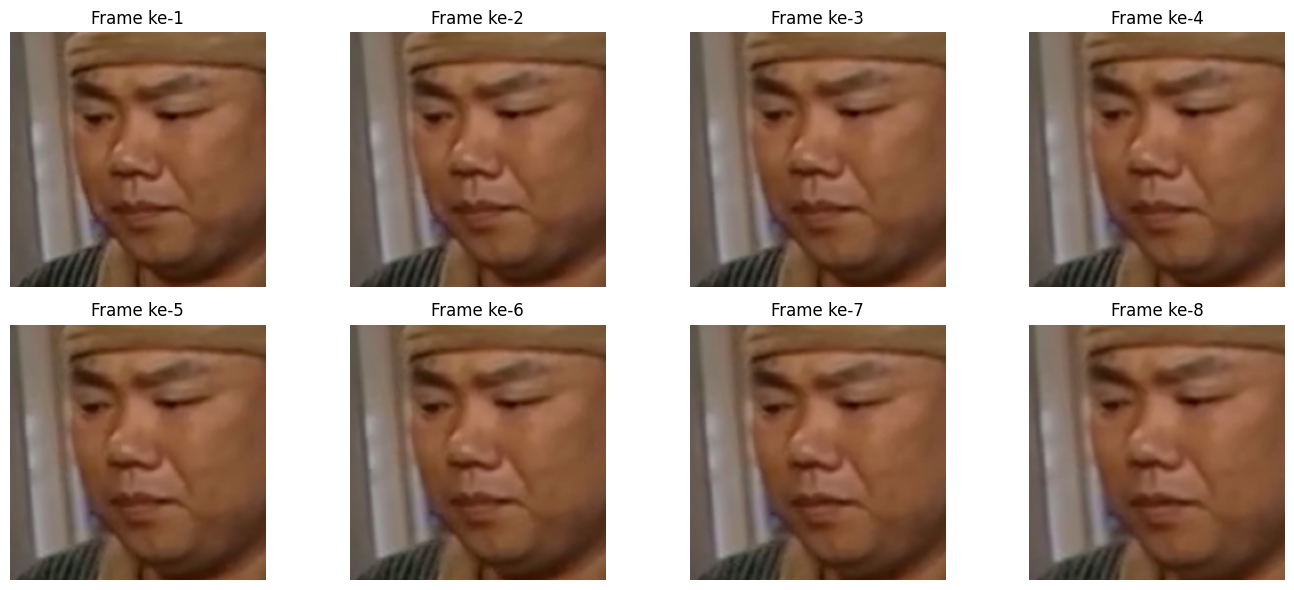

In [14]:
def denormalize_image(img_tensor, mean=NORM_MEAN, std=NORM_STD):
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = img * np.array(std) + np.array(mean)
    img = np.clip(img, 0, 1)
    return img

first_clip = sample_clips[0]  # [T, C, H, W]
num_show = min(8, first_clip.shape[0])

fig, axes = plt.subplots(2, math.ceil(num_show / 2), figsize=(14, 6))
axes = np.array(axes).reshape(-1)

for i in range(num_show):
    axes[i].imshow(denormalize_image(first_clip[i]))
    axes[i].set_title(f"Frame ke-{i+1}")
    axes[i].axis("off")

for i in range(num_show, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### 15. Focal Loss

In [15]:
class FocalLoss(nn.Module):
    """
    Focal Loss untuk klasifikasi multi-class berbasis logits.

    Pada notebook ini:
    - logits: [B, 2]
    - label : 0 = real, 1 = fake

    Rumus umum:
        FL = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """

    def __init__(self, gamma: float = 2.0, alpha=None, reduction: str = "mean"):
        super().__init__()

        if gamma < 0:
            raise ValueError("gamma harus bernilai >= 0.")

        if reduction not in {"mean", "sum", "none"}:
            raise ValueError("reduction harus salah satu dari: 'mean', 'sum', atau 'none'.")

        self.gamma = gamma
        self.reduction = reduction

        if alpha is None:
            self.alpha = None
        else:
            alpha = torch.as_tensor(alpha, dtype=torch.float32)
            self.register_buffer("alpha", alpha)

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        targets = targets.long()

        log_probs = torch.log_softmax(logits, dim=1)
        probs = torch.exp(log_probs)

        target_indices = targets.unsqueeze(1)

        log_pt = log_probs.gather(1, target_indices).squeeze(1)
        pt = probs.gather(1, target_indices).squeeze(1)

        focal_factor = (1.0 - pt).pow(self.gamma)
        loss = -focal_factor * log_pt

        if self.alpha is not None:
            alpha_t = self.alpha.gather(0, targets)
            loss = alpha_t * loss

        if self.reduction == "mean":
            return loss.mean()

        if self.reduction == "sum":
            return loss.sum()

        return loss

### 16. Linear Decay Scheduler

In [16]:
class LinearDecayLR(_LRScheduler):
    def __init__(self, optimizer, n_epoch, start_decay, last_epoch=-1, booster=2):
        self.start_decay = start_decay
        self.n_epoch = n_epoch
        self.booster = booster
        super(LinearDecayLR, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        last_epoch = self.last_epoch
        n_epoch = self.n_epoch
        b_lr = self.base_lrs[-1]

        if last_epoch > 0:
            try:
                cur_lr = self.get_last_lr()
            except Exception:
                cur_lr = b_lr * self.booster

        start_decay = self.start_decay

        if last_epoch >= start_decay:
            lr = b_lr * self.booster - (b_lr * self.booster) / (n_epoch - start_decay) * (last_epoch - start_decay)
        else:
            if last_epoch < start_decay:
                lr = b_lr + (b_lr * self.booster - b_lr) / start_decay * last_epoch
            else:
                lr = cur_lr

        self._last_lr = [lr]
        print(f"Active Learning Rate --- {lr}")
        return [lr for _ in self.optimizer.param_groups]

### 17. Model, Loss, Optimizer, Scheduler

In [17]:
model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=2,
    img_size=CFG.final_image_size,

    # Dropout ablation
    drop_rate=DROPOUT_RATE,
    attn_drop_rate=ATTENTION_DROPOUT_RATE,
    drop_path_rate=DROP_PATH_RATE,
)

model = model.to(DEVICE)

print("ViT image size:", model.patch_embed.img_size)
print("ViT num patches:", model.patch_embed.num_patches)
model = model.to(DEVICE)

if USE_FOCAL_LOSS:
    if USE_FOCAL_ALPHA:
        class_counts_series = train_split_df["label"].astype(int).value_counts().sort_index()

        class_counts = torch.tensor(
            [
                class_counts_series.get(0, 0),
                class_counts_series.get(1, 0),
            ],
            dtype=torch.float32,
        )

        if torch.any(class_counts == 0):
            raise ValueError(
                f"Terdapat kelas dengan jumlah sampel 0 pada data latih: {class_counts.tolist()}"
            )

        focal_alpha = class_counts.sum() / (len(class_counts) * class_counts)
        focal_alpha = focal_alpha / focal_alpha.mean()

        print("Menggunakan Focal Loss dengan alpha otomatis.")
        print("Class counts [real, fake] :", class_counts.tolist())
        print("Focal alpha  [real, fake] :", focal_alpha.tolist())

    else:
        focal_alpha = None
        print("Menggunakan Focal Loss tanpa alpha.")

    criterion = FocalLoss(
        gamma=FOCAL_GAMMA,
        alpha=focal_alpha,
        reduction="mean",
    ).to(DEVICE)

else:
    criterion = nn.CrossEntropyLoss()
    print("Menggunakan CrossEntropyLoss.")


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = CosineAnnealingLR(
    optimizer=optimizer,
    T_max=EPOCHS,
    eta_min=0.0,
)

scaler = torch.cuda.amp.GradScaler(enabled=USE_GRAD_SCALER)

print("Optimizer          :", optimizer.__class__.__name__)
print("Base learning rate :", LR)
print("Weight decay       :", WEIGHT_DECAY)
print("Scheduler          :", SCHEDULER_NAME)
print("Start decay epoch  :", SCHEDULER_START_DECAY)
print("Scheduler booster  :", SCHEDULER_BOOSTER)
print("Max active LR      :", LR * SCHEDULER_BOOSTER)
print("Loss aktif         :", criterion.__class__.__name__)

ViT image size: (224, 224)
ViT num patches: 196
Menggunakan CrossEntropyLoss.
Optimizer          : AdamW
Base learning rate : 5e-05
Weight decay       : 0.0001
Scheduler          : CosineAnnealingLR
Start decay epoch  : 6
Scheduler booster  : 2
Max active LR      : 0.0001
Loss aktif         : CrossEntropyLoss


### 18. Metrics

In [18]:
def compute_classification_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "precision_weighted": precision_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "recall_weighted": recall_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "f1_weighted": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "cm": cm,
        "y_pred": y_pred,
        "classification_report_text": classification_report(
            y_true,
            y_pred,
            labels=[0, 1],
            target_names=["real", "fake"],
            digits=4,
            zero_division=0,
        ),
        "classification_report_dict": classification_report(
            y_true,
            y_pred,
            labels=[0, 1],
            target_names=["real", "fake"],
            digits=4,
            zero_division=0,
            output_dict=True,
        ),
    }

    return metrics

### 19. Train/Eval Functions

In [19]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    scaler,
    device,
    epoch: int | None = None,
    total_epochs: int | None = None,
 ):
    """
    Training dilakukan pada tingkat klip agar fair dengan model spasiotemporal.

    Alur:
    1. DataLoader mengeluarkan batch [B, T, C, H, W]
    2. Backbone ViT memproses frame-level: [B*T, C, H, W]
    3. Untuk loss:
       - logits tiap frame di-reshape menjadi [B, T, 2]
       - kemudian dirata-ratakan pada tingkat klip -> [B, 2]
       - loss dihitung terhadap label klip menggunakan criterion yang aktif

    4. Untuk keputusan prediksi akhir di evaluasi:
       - probabilitas tiap frame dirata-ratakan pada tingkat klip
    """
    model.train()

    running_loss = 0.0
    total_samples = 0
    all_y_true = []
    all_y_pred = []

    if epoch is not None and total_epochs is not None:
        desc = f"Train {epoch:02d}/{total_epochs}"
    else:
        desc = "Train"

    progress_bar = tqdm(
        loader,
        desc=desc,
        total=len(loader),
        dynamic_ncols=True,
        leave=False,
    )

    for batch_idx, (clips, labels, meta) in enumerate(progress_bar, start=1):
        batch_start = time.time()
        b, t, c, h, w = clips.shape

        clips = clips.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        frames = clips.reshape(b * t, c, h, w)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP):
            frame_logits = model(frames)
            clip_logits = frame_logits.view(b, t, 2).mean(dim=1)
            loss = criterion(clip_logits, labels)
            preds = torch.argmax(clip_logits.detach().float(), dim=1)
            all_y_true.extend(labels.detach().cpu().numpy().tolist())
            all_y_pred.extend(preds.detach().cpu().numpy().tolist())

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * labels.size(0)
        total_samples += labels.size(0)

        avg_loss = running_loss / max(total_samples, 1)
        batch_time = time.time() - batch_start
        progress_bar.set_postfix({
            "loss": f"{avg_loss:.4f}",
            "batch_s": f"{batch_time:.1f}",
        })

        del clips, labels, frames, frame_logits, clip_logits, loss

    train_metrics = compute_classification_metrics(all_y_true, all_y_pred)
    train_metrics["loss"] = running_loss / max(total_samples, 1)

    return train_metrics


@torch.no_grad()
def evaluate_clip_level(
    model,
    loader,
    criterion,
    device,
    epoch: int | None = None,
    total_epochs: int | None = None,
 ):
    model.eval()

    running_loss = 0.0
    total_samples = 0

    all_y_true = []
    all_y_pred = []
    all_probs = []
    all_clip_dirs = []

    if epoch is not None and total_epochs is not None:
        desc = f"Valid {epoch:02d}/{total_epochs}"
    else:
        desc = "Valid"

    progress_bar = tqdm(
        loader,
        desc=desc,
        total=len(loader),
        dynamic_ncols=True,
        leave=False,
    )

    for batch_idx, (clips, labels, meta) in enumerate(progress_bar, start=1):
        batch_start = time.time()
        b, t, c, h, w = clips.shape

        clips = clips.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        frames = clips.reshape(b * t, c, h, w)

        with torch.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP):
            frame_logits = model(frames)
            clip_logits = frame_logits.view(b, t, 2).mean(dim=1)
            loss = criterion(clip_logits, labels)

        clip_probs = torch.softmax(clip_logits.float(), dim=1)
        preds = torch.argmax(clip_probs, dim=1)

        y_true = labels.detach().cpu().numpy()
        y_pred = preds.detach().cpu().numpy()
        prob_np = clip_probs.detach().cpu().numpy()

        all_y_true.extend(y_true.tolist())
        all_y_pred.extend(y_pred.tolist())
        all_probs.append(prob_np)
        all_clip_dirs.extend(meta["clip_dir"])

        running_loss += loss.item() * labels.size(0)
        total_samples += labels.size(0)

        avg_loss = running_loss / max(total_samples, 1)
        batch_time = time.time() - batch_start
        progress_bar.set_postfix({
            "val_loss": f"{avg_loss:.4f}",
            "batch_s": f"{batch_time:.1f}",
        })

        del clips, labels, frames, frame_logits, clip_logits, clip_probs, loss

    all_probs = np.concatenate(all_probs, axis=0)

    metric_dict = compute_classification_metrics(all_y_true, all_y_pred)
    metric_dict["loss"] = running_loss / max(total_samples, 1)
    metric_dict["y_true"] = np.array(all_y_true)
    metric_dict["y_pred"] = np.array(all_y_pred)
    metric_dict["y_prob_real"] = all_probs[:, 0]
    metric_dict["y_prob_fake"] = all_probs[:, 1]
    metric_dict["clip_dirs"] = all_clip_dirs

    return metric_dict

### 20. W&B Init

In [20]:
# INISIALISASI WEIGHTS & BIASES
wandb_run = None

def setup_wandb_login():
    if not USE_WANDB:
        return

    os.environ["WANDB_MODE"] = WANDB_MODE
    print(f"W&B mode: {os.environ['WANDB_MODE']}")


def build_wandb_config():
    return {
        "experiment_code": CFG.code,
        "experiment_description": CFG.description,
        "model_kind": MODEL_KIND,
        "num_classes": 2,
        "class_0": "real",
        "class_1": "fake",
        "source_clip_len": SOURCE_CLIP_LEN,
        "num_frames": CFG.num_frames,
        "stride": CFG.stride,
        "final_image_size": CFG.final_image_size,
        "downscale_first": CFG.downscale_first,
        "aug_geometry_oneof_prob": AUG_GEOMETRY_ONEOF_PROB,
        "aug_horizontal_flip": AUG_PROB_HFLIP,
        "aug_crop_limit": AUG_CROP_LIMIT,
        "aug_crop_prob": AUG_CROP_PROB,
        "aug_scale_limit": AUG_SCALE_LIMIT,
        "aug_scale_prob": AUG_SCALE_PROB,
        "aug_colorjitter_prob": AUG_COLORJITTER_PROB,
        "aug_colorjitter_brightness": AUG_COLORJITTER_BRIGHTNESS,
        "aug_colorjitter_contrast": AUG_COLORJITTER_CONTRAST,
        "aug_colorjitter_saturation": AUG_COLORJITTER_SATURATION,
        "aug_colorjitter_hue": AUG_COLORJITTER_HUE,
        "aug_blur_or_noise_oneof_prob": AUG_BLUR_OR_NOISE_ONEOF_PROB,
        "aug_gaussian_blur_prob": AUG_GAUSSIAN_BLUR_PROB,
        "aug_gaussian_blur_limit": AUG_GAUSSIAN_BLUR_LIMIT,
        "aug_gaussnoise_prob": AUG_GAUSSNOISE_PROB,
        "aug_gaussnoise_var_limit": AUG_GAUSSNOISE_VAR_LIMIT,
        "batch_size_clips": BATCH_SIZE_CLIPS,
        "epochs": EPOCHS,
        "learning_rate": LR,
        "weight_decay": WEIGHT_DECAY,
        "dropout_rate": DROPOUT_RATE,
        "attention_dropout_rate": ATTENTION_DROPOUT_RATE,
        "drop_path_rate": DROP_PATH_RATE,
        "optimizer": optimizer.__class__.__name__,
        "scheduler": SCHEDULER_NAME,
        "scheduler_start_decay": SCHEDULER_START_DECAY,
        "scheduler_booster": SCHEDULER_BOOSTER,
        "base_learning_rate": LR,
        "max_active_learning_rate": LR * SCHEDULER_BOOSTER,
        "use_early_stopping": USE_EARLY_STOPPING,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE if USE_EARLY_STOPPING else None,
        "loss_name": criterion.__class__.__name__,
        "use_focal_loss": USE_FOCAL_LOSS,
        "focal_gamma": FOCAL_GAMMA if USE_FOCAL_LOSS else None,
        "use_focal_alpha": USE_FOCAL_ALPHA if USE_FOCAL_LOSS else None,
        "train_size": len(train_dataset),
        "val_size": len(val_dataset),
        "test_size": len(test_dataset),
        "normalization_mean": NORM_MEAN,
        "normalization_std": NORM_STD,
        "checkpoint_selected_by": "val_accuracy",
        "evaluation_level": "clip_level",
    }


if USE_WANDB:
    setup_wandb_login()

    if wandb.run is not None:
        wandb.finish()

    wandb_run = wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name=WANDB_RUN_NAME,
        group=WANDB_GROUP,
        tags=WANDB_TAGS,
        config=build_wandb_config(),
        dir=str(OUTPUT_DIR),
        reinit=True,
    )

    wandb_run.define_metric("epoch")
    wandb_run.define_metric("train/*", step_metric="epoch")
    wandb_run.define_metric("valid/*", step_metric="epoch")
    wandb_run.define_metric("lr", step_metric="epoch")
    wandb_run.define_metric("time/*", step_metric="epoch")
    wandb_run.define_metric("test/*")

    print("W&B run aktif:", wandb_run.name)
else:
    print("W&B dinonaktifkan.")

W&B mode: online


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: afenmarbun (afenmarbun-institut-teknologi-sumatera) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


W&B run aktif: E05_spatial_vit_vit_base_patch16_224.mae


### 21. Training Loop & Checkpoint

In [21]:
history = []
best_state = None
best_epoch = 0
best_val_accuracy = float("-inf")
patience_counter = 0

checkpoint_path = OUTPUT_DIR / f"best_{CFG.code}_spatial_vit.pt"

start_time = time.time()

print("Mulai training...", flush=True)
print("Experiment code :", CFG.code, flush=True)
print("Device          :", DEVICE, flush=True)
print("Checkpoint path :", checkpoint_path, flush=True)
print("Jumlah epoch    :", EPOCHS, flush=True)
print("Train batches   :", len(train_loader), flush=True)
print("Valid batches   :", len(val_loader), flush=True)

epoch_bar = tqdm(
    range(1, EPOCHS + 1),
    desc=f"Training {CFG.code}",
    total=EPOCHS,
    dynamic_ncols=True,
 )

for epoch in epoch_bar:
    epoch_start = time.time()

    print(f"\n[{CFG.code}] Mulai epoch {epoch:02d}/{EPOCHS}", flush=True)

    train_result = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        scaler=scaler,
        device=DEVICE,
        epoch=epoch,
        total_epochs=EPOCHS,
    )

    train_loss = train_result["loss"]

    val_result = evaluate_clip_level(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=DEVICE,
        epoch=epoch,
        total_epochs=EPOCHS,
    )

    scheduler.step()

    epoch_time_sec = time.time() - epoch_start

    row = {
        "epoch": int(epoch),
        "train_loss": float(train_loss),
        "train_accuracy": float(train_result["accuracy"]),
        "train_precision_macro": float(train_result["precision_macro"]),
        "train_recall_macro": float(train_result["recall_macro"]),
        "train_f1_macro": float(train_result["f1_macro"]),
        "train_precision_weighted": float(train_result["precision_weighted"]),
        "train_recall_weighted": float(train_result["recall_weighted"]),
        "train_f1_weighted": float(train_result["f1_weighted"]),

        "val_loss": float(val_result["loss"]),
        "val_accuracy": float(val_result["accuracy"]),
        "val_precision_macro": float(val_result["precision_macro"]),
        "val_recall_macro": float(val_result["recall_macro"]),
        "val_f1_macro": float(val_result["f1_macro"]),
        "val_precision_weighted": float(val_result["precision_weighted"]),
        "val_recall_weighted": float(val_result["recall_weighted"]),
        "val_f1_weighted": float(val_result["f1_weighted"]),

        "lr": float(optimizer.param_groups[0]["lr"]),
        "epoch_time_sec": float(epoch_time_sec),
    }
    history.append(row)
    
    if wandb_run is not None:
        wandb_run.log(
            {
                "epoch": row["epoch"],

                "train/loss": row["train_loss"],
                "train/accuracy": row["train_accuracy"],
                "train/precision_macro": row["train_precision_macro"],
                "train/recall_macro": row["train_recall_macro"],
                "train/f1_macro": row["train_f1_macro"],
                "train/precision_weighted": row["train_precision_weighted"],
                "train/recall_weighted": row["train_recall_weighted"],
                "train/f1_weighted": row["train_f1_weighted"],

                "valid/loss": row["val_loss"],
                "valid/accuracy": row["val_accuracy"],
                "valid/precision_macro": row["val_precision_macro"],
                "valid/recall_macro": row["val_recall_macro"],
                "valid/f1_macro": row["val_f1_macro"],
                "valid/precision_weighted": row["val_precision_weighted"],
                "valid/recall_weighted": row["val_recall_weighted"],
                "valid/f1_weighted": row["val_f1_weighted"],

                "lr": row["lr"],
                "time/epoch_sec": row["epoch_time_sec"],
            },
            step=epoch,
        )

    epoch_bar.set_postfix({
        "train_loss": f"{train_loss:.4f}",
        "val_loss": f"{val_result['loss']:.4f}",
        "val_f1_macro": f"{val_result['f1_macro']:.4f}",
    })

    print(
        f"[{CFG.code}] Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"train_acc={train_result['accuracy']:.4f} | "
        f"train_f1_macro={train_result['f1_macro']:.4f} | "
        f"val_loss={val_result['loss']:.4f} | "
        f"val_acc={val_result['accuracy']:.4f} | "
        f"val_f1_macro={val_result['f1_macro']:.4f} | "
        f"epoch_time={epoch_time_sec/60:.2f} menit",
        flush=True,
    )

    current_val_accuracy = float(val_result["accuracy"])

    if current_val_accuracy > best_val_accuracy:
        best_val_accuracy = current_val_accuracy
        best_epoch = epoch
        patience_counter = 0
        
        model_state_cpu = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

        best_state = {
            "epoch": int(epoch),
            "experiment_code": str(CFG.code),
            "experiment_config": dict(CFG.__dict__),
            "model_name": str(MODEL_NAME),
            "checkpoint_selected_by": "val_accuracy",

            "loss_name": str(criterion.__class__.__name__),
            "use_focal_loss": bool(USE_FOCAL_LOSS),
            "focal_gamma": float(FOCAL_GAMMA) if USE_FOCAL_LOSS else None,
            "use_focal_alpha": bool(USE_FOCAL_ALPHA) if USE_FOCAL_LOSS else None,

            "model_state_dict": model_state_cpu,
            
            "best_val_accuracy": float(val_result["accuracy"]),
            "best_val_loss": float(val_result["loss"]),
            "best_val_precision_macro": float(val_result["precision_macro"]),
            "best_val_recall_macro": float(val_result["recall_macro"]),
            "best_val_f1_macro": float(val_result["f1_macro"]),
            "best_val_precision_weighted": float(val_result["precision_weighted"]),
            "best_val_recall_weighted": float(val_result["recall_weighted"]),
            "best_val_f1_weighted": float(val_result["f1_weighted"]),
        }

        torch.save(best_state, checkpoint_path)
        
        if wandb_run is not None:
            wandb_run.summary["best_epoch"] = int(epoch)
            wandb_run.summary["best/val_accuracy"] = float(val_result["accuracy"])
            wandb_run.summary["best/val_loss"] = float(val_result["loss"])
            wandb_run.summary["best/val_precision_macro"] = float(val_result["precision_macro"])
            wandb_run.summary["best/val_recall_macro"] = float(val_result["recall_macro"])
            wandb_run.summary["best/val_f1_macro"] = float(val_result["f1_macro"])
            wandb_run.summary["best/val_precision_weighted"] = float(val_result["precision_weighted"])
            wandb_run.summary["best/val_recall_weighted"] = float(val_result["recall_weighted"])
            wandb_run.summary["best/val_f1_weighted"] = float(val_result["f1_weighted"])

        print(
            f"  -> checkpoint terbaik disimpan berdasarkan "
            f"val_accuracy={best_val_accuracy:.4f}: {checkpoint_path}",
            flush=True,
        )

    else:
        if USE_EARLY_STOPPING:
            patience_counter += 1

            print(
                f"  -> val_accuracy tidak membaik, "
                f"patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}",
                flush=True,
            )

            if patience_counter >= EARLY_STOPPING_PATIENCE:
                print("\nEarly stopping aktif.", flush=True)
                break

        else:
            print(
                "  -> val_accuracy tidak membaik; early stopping dinonaktifkan, training tetap dilanjutkan.",
                flush=True,
            )

    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

total_time = time.time() - start_time
print(f"\nTraining selesai dalam {total_time/60:.2f} menit.", flush=True)
print(f"Best epoch: {best_epoch}", flush=True)
print(f"Best validation accuracy: {best_val_accuracy:.4f}", flush=True)

history_df = pd.DataFrame(history)

history_df = history_df[
    [
        "epoch",
        "train_loss",
        "train_accuracy",
        "train_precision_macro",
        "train_recall_macro",
        "train_f1_macro",
        "train_precision_weighted",
        "train_recall_weighted",
        "train_f1_weighted",

        "val_loss",
        "val_accuracy",
        "val_precision_macro",
        "val_recall_macro",
        "val_f1_macro",
        "val_precision_weighted",
        "val_recall_weighted",
        "val_f1_weighted",

        "lr",
        "epoch_time_sec",
    ]
]

history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False)

if wandb_run is not None:
    wandb_run.log(
        {
            "training/history_table": wandb.Table(dataframe=history_df)
        },
        step=int(history_df["epoch"].max()),
    )
    
display(history_df.tail())

Mulai training...
Experiment code : E05
Device          : cuda
Checkpoint path : /workspace/experiments/spatial_vit/E05/best_E05_spatial_vit.pt
Jumlah epoch    : 25
Train batches   : 485
Valid batches   : 112


Training E05:   0% 0/25 [00:00<?, ?it/s]


[E05] Mulai epoch 01/25


Train 01/25:   0% 0/485 [00:03<?, ?it/s]

Valid 01/25:   0% 0/112 [00:00<?, ?it/s]

...

[E05] Epoch 24 | train_loss=0.1937 | train_acc=0.9015 | train_f1_macro=0.8836 | val_loss=0.2363 | val_acc=0.9462 | val_f1_macro=0.9434 | epoch_time=4.29 menit
  -> checkpoint terbaik disimpan berdasarkan val_accuracy=0.9462: /workspace/experiments/spatial_vit/E05/best_E05_spatial_vit.pt

[E05] Mulai epoch 25/25


Train 25/25:   0% 0/485 [00:00<?, ?it/s]

Valid 25/25:   0% 0/112 [00:00<?, ?it/s]

[E05] Epoch 25 | train_loss=0.1948 | train_acc=0.9021 | train_f1_macro=0.8846 | val_loss=0.2368 | val_acc=0.9457 | val_f1_macro=0.9427 | epoch_time=4.30 menit
  -> val_accuracy tidak membaik; early stopping dinonaktifkan, training tetap dilanjutkan.

Training selesai dalam 159.51 menit.
Best epoch: 24
Best validation accuracy: 0.9462


,epoch,train_loss,train_accuracy,train_precision_macro,train_recall_macro,train_f1_macro,train_precision_weighted,train_recall_weighted,train_f1_weighted,val_loss,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_precision_weighted,val_recall_weighted,val_f1_weighted,lr,epoch_time_sec
20,21,0.202664,0.897097,0.921000,0.856802,0.878187,0.905799,0.897097,0.892889,0.235664,0.945954,0.942594,0.943645,0.943113,0.946030,0.945954,0.945986,3.092333e-06,257.212468
21,22,0.197068,0.900065,0.925296,0.859859,0.881629,0.909293,0.900065,0.895939,0.247267,0.943993,0.939429,0.943247,0.941240,0.944413,0.943993,0.944114,1.755588e-06,258.283832
22,23,0.199722,0.897290,0.921978,0.856645,0.878291,0.906349,0.897290,0.893021,0.239041,0.945954,0.942791,0.943378,0.943083,0.945993,0.945954,0.945971,7.854210e-07,257.495710
23,24,0.193746,0.901484,0.925089,0.862473,0.883646,0.909923,0.901484,0.897601,0.236266,0.946234,0.942744,0.944140,0.943430,0.946341,0.946234,0.946276,1.971325e-07,257.282857
24,25,0.194827,0.902129,0.924836,0.863752,0.884586,0.910144,0.902129,0.898370,0.236764,0.945673,0.942958,0.942483,0.942719,0.945647,0.945673,0.945659,0.000000e+00,258.024781


### 22. Training Curves

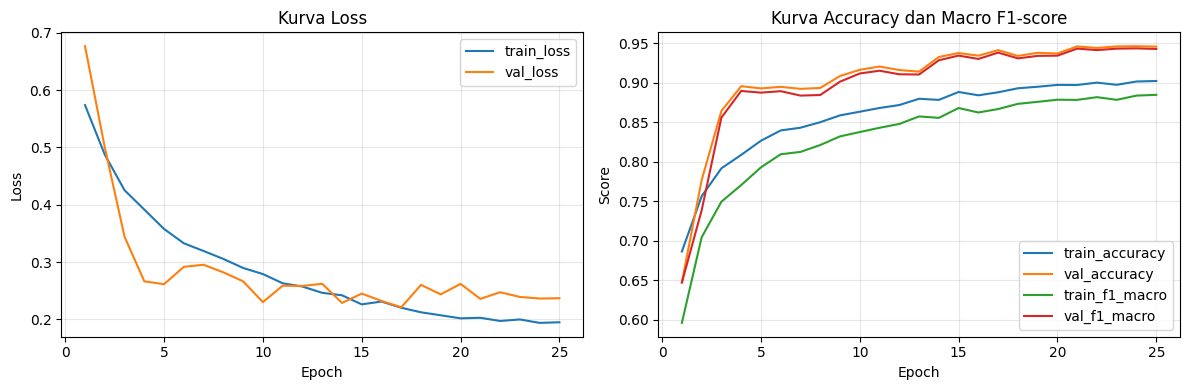

Plot history disimpan: /workspace/experiments/spatial_vit/E05/training_history.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
axes[0].set_title("Kurva Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["train_accuracy"], label="train_accuracy")
axes[1].plot(history_df["epoch"], history_df["val_accuracy"], label="val_accuracy")
axes[1].plot(history_df["epoch"], history_df["train_f1_macro"], label="train_f1_macro")
axes[1].plot(history_df["epoch"], history_df["val_f1_macro"], label="val_f1_macro")
axes[1].set_title("Kurva Accuracy dan Macro F1-score")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

history_plot_path = OUTPUT_DIR / "training_history.png"
plt.savefig(history_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Plot history disimpan:", history_plot_path)

### 23. Training Summary

In [23]:
if best_state is None:
    raise RuntimeError(
        "best_state masih None. Artinya belum ada checkpoint yang berhasil disimpan."
    )

summary_df = pd.DataFrame([{
    "experiment_code": CFG.code,
    "experiment_description": CFG.description,
    "model_name": MODEL_NAME,
    "checkpoint_path": str(checkpoint_path),
    "num_frames": CFG.num_frames,
    "stride": CFG.stride,
    "final_image_size": CFG.final_image_size,
    "downscale_first": CFG.downscale_first,
    "batch_size_clips": BATCH_SIZE_CLIPS,
    "checkpoint_selected_by": best_state.get("checkpoint_selected_by", "val_accuracy"),
    "loss_name": best_state.get("loss_name", criterion.__class__.__name__),
    "use_focal_loss": best_state.get("use_focal_loss", USE_FOCAL_LOSS),
    "focal_gamma": best_state.get("focal_gamma", FOCAL_GAMMA if USE_FOCAL_LOSS else None),
    "use_focal_alpha": best_state.get("use_focal_alpha", USE_FOCAL_ALPHA if USE_FOCAL_LOSS else None),
    "best_epoch": best_state["epoch"],
    "best_val_accuracy": best_state["best_val_accuracy"],
    "best_val_loss": best_state["best_val_loss"],
    "best_val_precision_macro": best_state["best_val_precision_macro"],
    "best_val_recall_macro": best_state["best_val_recall_macro"],
    "best_val_f1_macro": best_state["best_val_f1_macro"],
    "best_val_precision_weighted": best_state["best_val_precision_weighted"],
    "best_val_recall_weighted": best_state["best_val_recall_weighted"],
    "best_val_f1_weighted": best_state["best_val_f1_weighted"],
}])

training_summary_path = OUTPUT_DIR / "training_summary.csv"
summary_df.to_csv(training_summary_path, index=False)

if wandb_run is not None:
    wandb_run.log({
        "training/summary_table": wandb.Table(dataframe=summary_df)
    })

print("Training summary disimpan:", training_summary_path)
display(summary_df)

Training summary disimpan: /workspace/experiments/spatial_vit/E05/training_summary.csv


,experiment_code,experiment_description,model_name,checkpoint_path,num_frames,stride,final_image_size,downscale_first,batch_size_clips,checkpoint_selected_by,...,use_focal_alpha,best_epoch,best_val_accuracy,best_val_loss,best_val_precision_macro,best_val_recall_macro,best_val_f1_macro,best_val_precision_weighted,best_val_recall_weighted,best_val_f1_weighted
0,E05,Jumlah frame lebih panjang dengan 24 frame dan...,vit_base_patch16_224.mae,/workspace/experiments/spatial_vit/E05/best_E0...,24,1,224,None,32,val_accuracy,...,None,24,0.946234,0.236266,0.942744,0.94414,0.94343,0.946341,0.946234,0.946276


### 24. Final Test Evaluation

In [24]:
# FINAL TESTING PADA DATA TEST
test_output_dir = OUTPUT_DIR / "test_results"
test_output_dir.mkdir(parents=True, exist_ok=True)
checkpoint_path = OUTPUT_DIR / f"best_{CFG.code}_spatial_vit.pt"

if not checkpoint_path.exists():
    raise FileNotFoundError(
        f"Checkpoint terbaik tidak ditemukan: {checkpoint_path}\n"
        "Pastikan cell training sudah dijalankan sampai checkpoint tersimpan."
    )

print("Memuat checkpoint terbaik:")
print(checkpoint_path)

try:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )
except TypeError:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
    )

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

print("\nInformasi checkpoint:")
print("Experiment code       :", checkpoint.get("experiment_code"))
print("Best epoch            :", checkpoint.get("epoch"))
print("Selected by           :", checkpoint.get("checkpoint_selected_by"))
print("Best val accuracy     :", checkpoint.get("best_val_accuracy"))
print("Best val F1 macro     :", checkpoint.get("best_val_f1_macro"))
print("Best val precision macro:", checkpoint.get("best_val_precision_macro"))
print("Best val recall macro :", checkpoint.get("best_val_recall_macro"))
print("\nMulai evaluasi pada data test...")

test_result = evaluate_clip_level(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=DEVICE,
)

test_metrics = {
    "experiment_code": CFG.code,
    "description": CFG.description,
    "checkpoint_path": str(checkpoint_path),
    "best_epoch": int(checkpoint.get("epoch")),
    "checkpoint_selected_by": checkpoint.get("checkpoint_selected_by"),
    "test_loss": float(test_result["loss"]),
    "test_accuracy": float(test_result["accuracy"]),
    "test_precision_macro": float(test_result["precision_macro"]),
    "test_recall_macro": float(test_result["recall_macro"]),
    "test_f1_macro": float(test_result["f1_macro"]),
    "test_precision_weighted": float(test_result["precision_weighted"]),
    "test_recall_weighted": float(test_result["recall_weighted"]),
    "test_f1_weighted": float(test_result["f1_weighted"]),
}

print("\n HASIL FINAL TEST : ")
print(f"Test loss                : {test_metrics['test_loss']:.4f}")
print(f"Test accuracy            : {test_metrics['test_accuracy']:.4f}")
print(f"Test precision macro     : {test_metrics['test_precision_macro']:.4f}")
print(f"Test recall macro        : {test_metrics['test_recall_macro']:.4f}")
print(f"Test F1-score macro      : {test_metrics['test_f1_macro']:.4f}")
print(f"Test precision weighted  : {test_metrics['test_precision_weighted']:.4f}")
print(f"Test recall weighted     : {test_metrics['test_recall_weighted']:.4f}")
print(f"Test F1-score weighted   : {test_metrics['test_f1_weighted']:.4f}")

print("\nConfusion Matrix")
print("Baris  : label aktual [real, fake]")
print("Kolom  : label prediksi [real, fake]")
print(test_result["cm"])


# SIMPAN METRIK TEST
test_metrics_csv_path = test_output_dir / "test_metrics.csv"
test_metrics_json_path = test_output_dir / "test_metrics.json"

pd.DataFrame([test_metrics]).to_csv(test_metrics_csv_path, index=False)
with open(test_metrics_json_path, "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, indent=2)


# SIMPAN PREDIKSI PER KLIP

test_pred_df = pd.DataFrame({
    "clip_dir": test_result["clip_dirs"],
    "y_true": test_result["y_true"].astype(int),
    "y_pred": test_result["y_pred"].astype(int),
    "y_prob_real": test_result["y_prob_real"].astype(float),
    "y_prob_fake": test_result["y_prob_fake"].astype(float),
})

test_pred_df["y_true_label"] = test_pred_df["y_true"].map(IDX_TO_CLASS)
test_pred_df["y_pred_label"] = test_pred_df["y_pred"].map(IDX_TO_CLASS)
test_pred_df["is_correct"] = test_pred_df["y_true"] == test_pred_df["y_pred"]

classification_report_df = pd.DataFrame(test_result["classification_report_dict"]).T
classification_report_path = test_output_dir / "test_classification_report.csv"
classification_report_df.to_csv(classification_report_path)

if wandb_run is not None:
    wandb_run.log({
        "test/classification_report": wandb.Table(
            dataframe=classification_report_df.reset_index()
        )
    })

print("Classification report:", classification_report_path)
print("\nClassification Report")
print(test_result["classification_report_text"])

test_predictions_csv_path = test_output_dir / "test_predictions_clip_level.csv"
test_pred_df.to_csv(test_predictions_csv_path, index=False)

if wandb_run is not None:
    wandb_run.log({
        "test/predictions_clip_level_sample": wandb.Table(
            dataframe=test_pred_df.head(1000)
        )
    })

print("\nFile hasil testing disimpan:")
print("Metrik CSV       :", test_metrics_csv_path)
print("Metrik JSON      :", test_metrics_json_path)
print("Prediksi per klip:", test_predictions_csv_path)

display(test_pred_df.head())

Memuat checkpoint terbaik:
/workspace/experiments/spatial_vit/E05/best_E05_spatial_vit.pt

Informasi checkpoint:
Experiment code       : E05
Best epoch            : 24
Selected by           : val_accuracy
Best val accuracy     : 0.9462335480257631
Best val F1 macro     : 0.9434297776504585
Best val precision macro: 0.9427439864660475
Best val recall macro : 0.9441401852044065

Mulai evaluasi pada data test...


Valid:   0% 0/101 [00:05<?, ?it/s]


 HASIL FINAL TEST : 
Test loss                : 0.9648
Test accuracy            : 0.7933
Test precision macro     : 0.7733
Test recall macro        : 0.7958
Test F1-score macro      : 0.7795
Test precision weighted  : 0.8101
Test recall weighted     : 0.7933
Test F1-score weighted   : 0.7974

Confusion Matrix
Baris  : label aktual [real, fake]
Kolom  : label prediksi [real, fake]
[[ 878  215]
 [ 453 1686]]
Classification report: /workspace/experiments/spatial_vit/E05/test_results/test_classification_report.csv

Classification Report
              precision    recall  f1-score   support

        real     0.6597    0.8033    0.7244      1093
        fake     0.8869    0.7882    0.8347      2139

    accuracy                         0.7933      3232
   macro avg     0.7733    0.7958    0.7795      3232
weighted avg     0.8101    0.7933    0.7974      3232


File hasil testing disimpan:
Metrik CSV       : /workspace/experiments/spatial_vit/E05/test_results/test_metrics.csv
Metrik JSON    

,clip_dir,y_true,y_pred,y_prob_real,y_prob_fake,y_true_label,y_pred_label,is_correct
0,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,0,0.999831,0.000169,real,real,True
1,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,0,0.999943,0.000056,real,real,True
2,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,0,0.992879,0.007121,real,real,True
3,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,0,0.998935,0.001065,real,real,True
4,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,0,0.998793,0.001207,real,real,True


### 25. W&B Test Logging

In [25]:
if wandb_run is not None:
    wandb_run.log({
        "test/loss": test_metrics["test_loss"],
        "test/accuracy": test_metrics["test_accuracy"],
        "test/precision_macro": test_metrics["test_precision_macro"],
        "test/recall_macro": test_metrics["test_recall_macro"],
        "test/f1_macro": test_metrics["test_f1_macro"],
        "test/precision_weighted": test_metrics["test_precision_weighted"],
        "test/recall_weighted": test_metrics["test_recall_weighted"],
        "test/f1_weighted": test_metrics["test_f1_weighted"],
    })

    wandb_run.summary["test/loss"] = test_metrics["test_loss"]
    wandb_run.summary["test/accuracy"] = test_metrics["test_accuracy"]
    wandb_run.summary["test/precision_macro"] = test_metrics["test_precision_macro"]
    wandb_run.summary["test/recall_macro"] = test_metrics["test_recall_macro"]
    wandb_run.summary["test/f1_macro"] = test_metrics["test_f1_macro"]
    wandb_run.summary["test/precision_weighted"] = test_metrics["test_precision_weighted"]
    wandb_run.summary["test/recall_weighted"] = test_metrics["test_recall_weighted"]
    wandb_run.summary["test/f1_weighted"] = test_metrics["test_f1_weighted"]

### 26. Confusion Matrix Plot

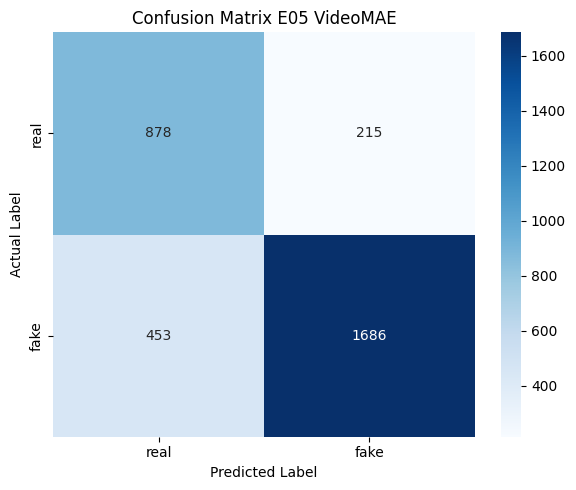

Confusion matrix disimpan: /workspace/experiments/spatial_vit/E05/test_results/test_confusion_matrix.png


In [26]:
# VISUALISASI HASIL TESTING

cm = test_result["cm"]
class_names = [IDX_TO_CLASS[i] for i in sorted(IDX_TO_CLASS.keys())]  # ["real", "fake"]

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(f"Confusion Matrix {CFG.code} VideoMAE")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()

confusion_matrix_path = test_output_dir / "test_confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=200, bbox_inches="tight")
plt.show()

if wandb_run is not None:
    wandb_run.log({
        "test/confusion_matrix": wandb.Image(str(confusion_matrix_path))
    })

print("Confusion matrix disimpan:", confusion_matrix_path)

### 27. Misclassified Analysis

In [27]:
# ANALISIS SAMPEL YANG SALAH PREDIKSI

misclassified_df = test_pred_df[test_pred_df["is_correct"] == False].copy()

print("Jumlah seluruh klip test       :", len(test_pred_df))
print("Jumlah salah prediksi          :", len(misclassified_df))
print("Persentase salah prediksi (%)  :", 100 * len(misclassified_df) / max(len(test_pred_df), 1))

display(
    misclassified_df.sort_values(
        by="y_prob_fake",
        ascending=False,
    ).head(30)
)

misclassified_csv_path = test_output_dir / "test_misclassified_clip_level.csv"
misclassified_df.to_csv(misclassified_csv_path, index=False)

print("Data salah prediksi disimpan:", misclassified_csv_path)

Jumlah seluruh klip test       : 3232
Jumlah salah prediksi          : 668
Persentase salah prediksi (%)  : 20.668316831683168


,clip_dir,y_true,y_pred,y_prob_real,y_prob_fake,y_true_label,y_pred_label,is_correct
1030,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.000010,0.999990,real,fake,False
1015,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.000015,0.999985,real,fake,False
452,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.000019,0.999981,real,fake,False
291,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.000020,0.999980,real,fake,False
204,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.000021,0.999979,real,fake,False
126,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.000024,0.999976,real,fake,False
1038,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.000028,0.999972,real,fake,False
1071,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.000029,0.999971,real,fake,False
1036,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.000040,0.999960,real,fake,False
1010,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.000043,0.999957,real,fake,False


Data salah prediksi disimpan: /workspace/experiments/spatial_vit/E05/test_results/test_misclassified_clip_level.csv


### 28. Grad-CAM Visualization

Memuat checkpoint terbaik untuk Grad-CAM:
/workspace/experiments/spatial_vit/E05/best_E05_spatial_vit.pt
Checkpoint berhasil dimuat.
Best epoch        : 24
Best val accuracy : 0.9462335480257631
Grad-CAM ViT grid size: 14 x 14

Sampel test index : 0
Clip dir          : /workspace/wdf46f_runtime/wilddeepfake-46f/wilddeepfake_46f_merged_v5/real_test/104/10_0
Label aktual      : real
Prediksi model    : real
Prob(real)        : 0.9998
Prob(fake)        : 0.0002
Target Grad-CAM   : real
Sampled indices   : tensor([11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28,
        29, 30, 31, 32, 33, 34])


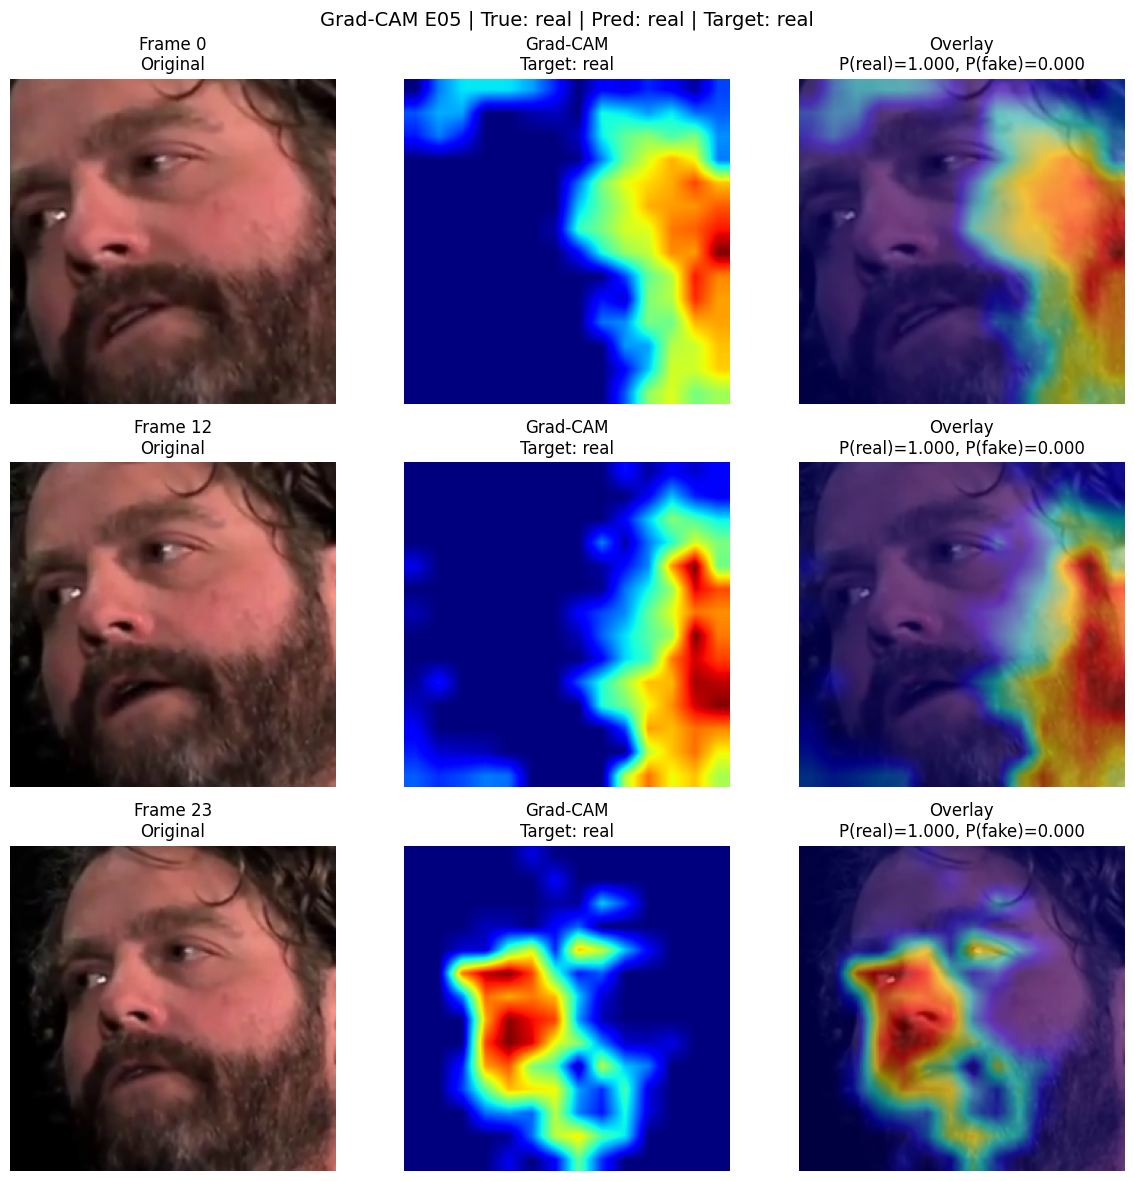

Grad-CAM sampel disimpan di: /workspace/experiments/spatial_vit/E05/gradcam_results/test_index_0000
Ringkasan gambar            : /workspace/experiments/spatial_vit/E05/gradcam_results/test_index_0000/gradcam_summary.png

Sampel test index : 1
Clip dir          : /workspace/wdf46f_runtime/wilddeepfake-46f/wilddeepfake_46f_merged_v5/real_test/104/10_1
Label aktual      : real
Prediksi model    : real
Prob(real)        : 0.9999
Prob(fake)        : 0.0001
Target Grad-CAM   : real
Sampled indices   : tensor([11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28,
        29, 30, 31, 32, 33, 34])


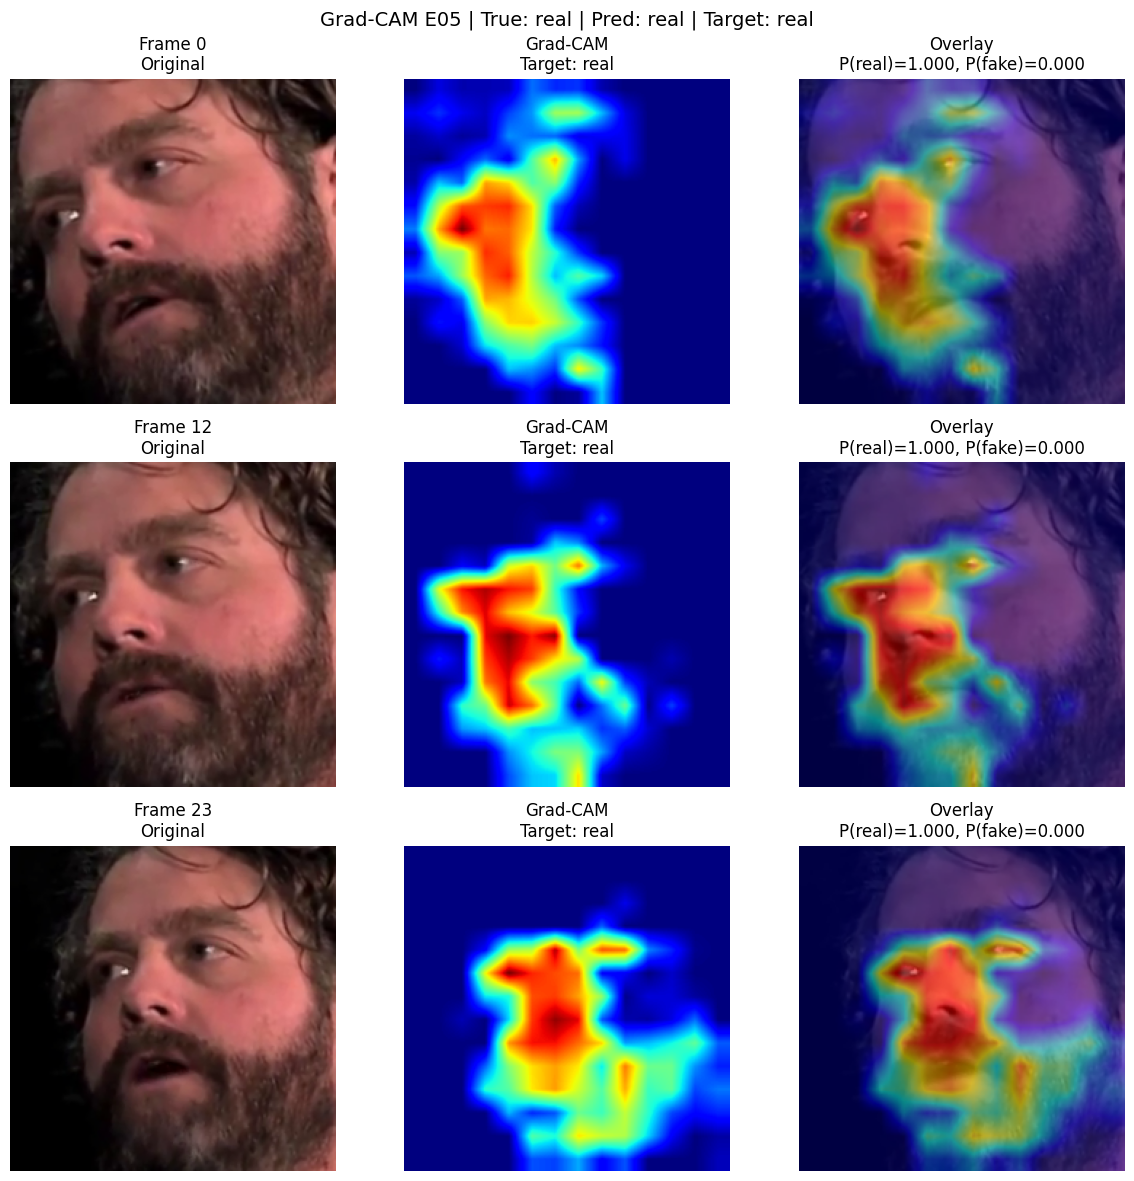

Grad-CAM sampel disimpan di: /workspace/experiments/spatial_vit/E05/gradcam_results/test_index_0001
Ringkasan gambar            : /workspace/experiments/spatial_vit/E05/gradcam_results/test_index_0001/gradcam_summary.png

Sampel test index : 2
Clip dir          : /workspace/wdf46f_runtime/wilddeepfake-46f/wilddeepfake_46f_merged_v5/real_test/104/13_0
Label aktual      : real
Prediksi model    : real
Prob(real)        : 0.9927
Prob(fake)        : 0.0073
Target Grad-CAM   : real
Sampled indices   : tensor([11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28,
        29, 30, 31, 32, 33, 34])


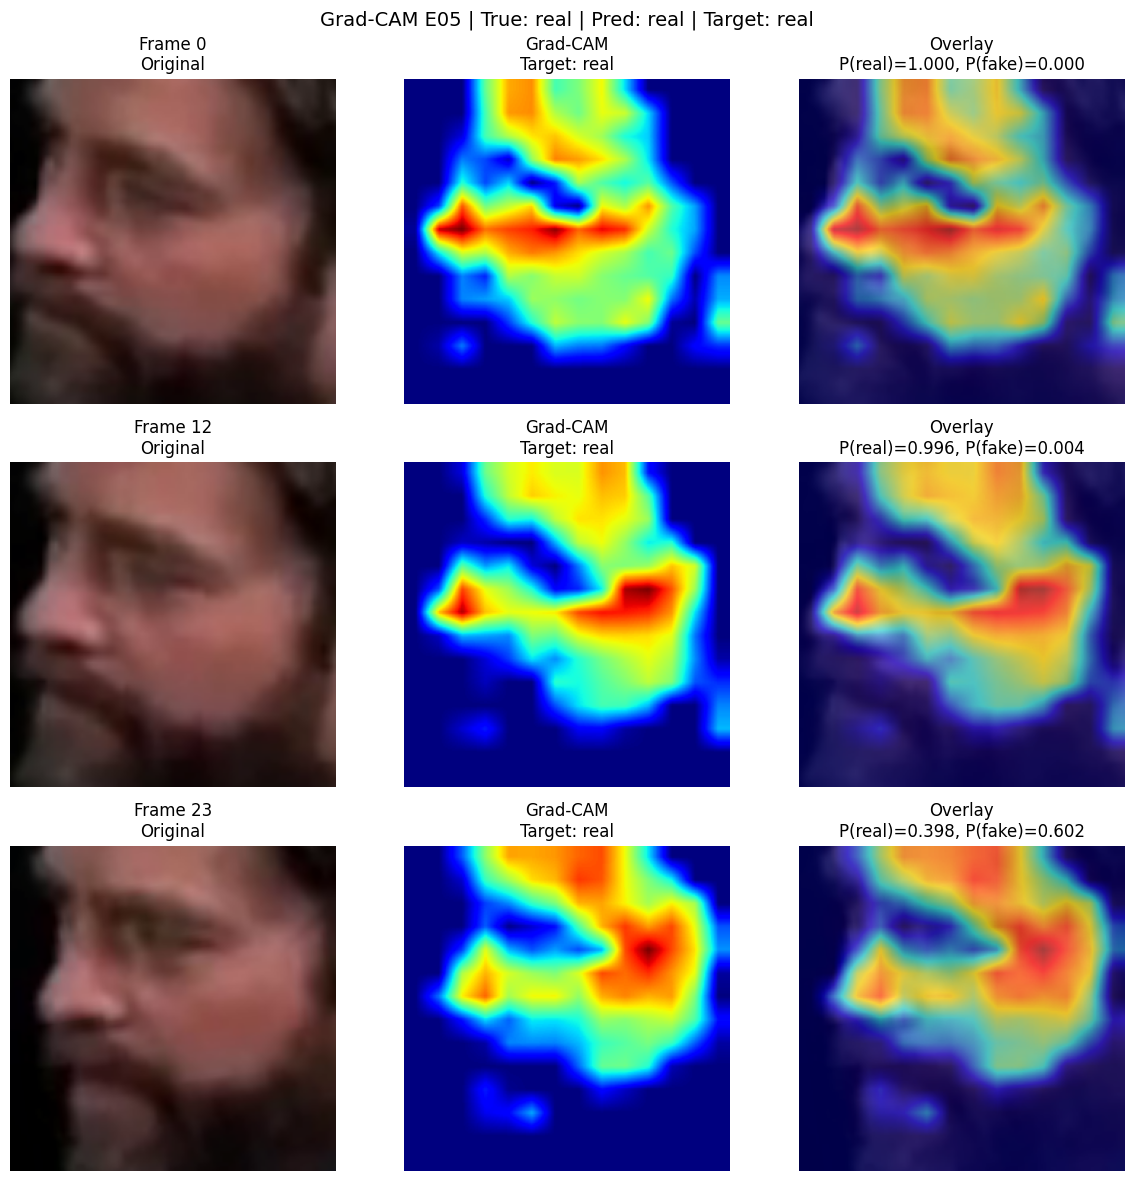

Grad-CAM sampel disimpan di: /workspace/experiments/spatial_vit/E05/gradcam_results/test_index_0002
Ringkasan gambar            : /workspace/experiments/spatial_vit/E05/gradcam_results/test_index_0002/gradcam_summary.png

Proses Grad-CAM selesai.
Folder output: /workspace/experiments/spatial_vit/E05/gradcam_results


In [28]:
# GRAD-CAM UNTUK MODEL SPASIAL VISION TRANSFORMER

gradcam_output_dir = OUTPUT_DIR / "gradcam_results"
gradcam_output_dir.mkdir(parents=True, exist_ok=True)

# Pilih indeks sampel dari test_dataset.
GRADCAM_SAMPLE_INDICES = [0, 1, 2]

# Pilih frame yang ingin divisualisasikan dari hasil sampling.
# Untuk E01 dengan 16 frame: frame 0, tengah, dan terakhir.
GRADCAM_FRAME_INDICES = sorted(set([
    0,
    CFG.num_frames // 2,
    CFG.num_frames - 1,
]))

# Pilihan target:
# - "predicted" : Grad-CAM mengikuti kelas prediksi model
# - "true"      : Grad-CAM mengikuti label aktual
# - "fake"      : Grad-CAM khusus untuk kelas fake
# - "real"      : Grad-CAM khusus untuk kelas real
GRADCAM_TARGET_MODE = "predicted"

# Smoothing membuat heatmap lebih halus, tetapi lebih lambat.
USE_AUG_SMOOTH = False
USE_EIGEN_SMOOTH = True


# MUAT CHECKPOINT TERBAIK
checkpoint_path = OUTPUT_DIR / f"best_{CFG.code}_spatial_vit.pt"
if not checkpoint_path.exists():
    raise FileNotFoundError(
        f"Checkpoint terbaik tidak ditemukan: {checkpoint_path}\n"
        "Jalankan training terlebih dahulu sampai checkpoint tersimpan."
    )

print("Memuat checkpoint terbaik untuk Grad-CAM:")
print(checkpoint_path)

try:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )
except TypeError:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
    )

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

for param in model.parameters():
    param.requires_grad_(True)

print("Checkpoint berhasil dimuat.")
print("Best epoch        :", checkpoint.get("epoch"))
print("Best val accuracy :", checkpoint.get("best_val_accuracy"))


vit_grid_size = CFG.final_image_size // model.patch_embed.patch_size[0]

def vit_reshape_transform(tensor, height=vit_grid_size, width=vit_grid_size):
    result = tensor[:, 1:, :].reshape(
        tensor.size(0),
        height,
        width,
        tensor.size(2),
    )
    result = result.permute(0, 3, 1, 2)
    return result

print("Grad-CAM ViT grid size:", vit_grid_size, "x", vit_grid_size)


# Target layer untuk ViT.
# Untuk timm ViT, struktur umumnya memiliki model.blocks.
target_layers = [model.blocks[-1].norm1]

def get_clip_prediction_spatial_vit(model, clip_tensor, device):
    """
    Menghasilkan prediksi tingkat klip dari model spasial ViT.

    Input:
        clip_tensor: [T, C, H, W]

    Output:
        clip_prob  : probabilitas tingkat klip [2]
        frame_prob : probabilitas tiap frame [T, 2], hanya untuk informasi visual
        pred_class : kelas prediksi tingkat klip
    """
    model.eval()

    with torch.no_grad():
        frames = clip_tensor.to(device)          # [T, C, H, W]
        logits = model(frames)                  # [T, 2]

        clip_logits = logits.mean(dim=0)        # [2]
        clip_prob = torch.softmax(
            clip_logits.float(),
            dim=0,
        )

        frame_prob = torch.softmax(
            logits.float(),
            dim=1,
        )

        pred_class = int(torch.argmax(clip_prob).item())

    return (
        clip_prob.detach().cpu(),
        frame_prob.detach().cpu(),
        pred_class,
    )


def resolve_gradcam_target_class(mode, pred_class, true_class):
    """
    Menentukan kelas target Grad-CAM.
    """
    if mode == "predicted":
        return int(pred_class)

    if mode == "true":
        return int(true_class)

    if mode == "fake":
        return CLASS_TO_IDX["fake"]

    if mode == "real":
        return CLASS_TO_IDX["real"]

    raise ValueError(
        "GRADCAM_TARGET_MODE harus salah satu dari: "
        "'predicted', 'true', 'fake', atau 'real'."
    )


def make_gradcam_for_frame(
    model,
    frame_tensor,
    target_class,
    cam,
    device,
):
    """
    Membuat Grad-CAM untuk satu frame.

    Input:
        frame_tensor : [C, H, W]
        target_class : 0 real atau 1 fake

    Output:
        rgb_img       : citra RGB denormalisasi [0, 1]
        grayscale_cam : heatmap Grad-CAM [H, W]
        visualization : overlay heatmap pada citra asli
    """
    input_tensor = frame_tensor.unsqueeze(0).to(device)  # [1, C, H, W]

    targets = [ClassifierOutputTarget(target_class)]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets,
        aug_smooth=USE_AUG_SMOOTH,
        eigen_smooth=USE_EIGEN_SMOOTH,
    )

    grayscale_cam = grayscale_cam[0, :]

    rgb_img = denormalize_image(frame_tensor)
    visualization = show_cam_on_image(
        rgb_img.astype(np.float32),
        grayscale_cam,
        use_rgb=True,
    )

    return rgb_img, grayscale_cam, visualization


# PROSES GRAD-CAM
with GradCAM(
    model=model,
    target_layers=target_layers,
    reshape_transform=vit_reshape_transform,
) as cam:

    for sample_idx in GRADCAM_SAMPLE_INDICES:
        if sample_idx < 0 or sample_idx >= len(test_dataset):
            print(f"Indeks {sample_idx} dilewati karena di luar rentang test_dataset.")
            continue

        clip_tensor, label_tensor, meta = test_dataset[sample_idx]

        true_class = int(label_tensor.item())
        true_label = IDX_TO_CLASS[true_class]

        clip_prob, frame_prob, pred_class = get_clip_prediction_spatial_vit(
            model=model,
            clip_tensor=clip_tensor,
            device=DEVICE,
        )

        pred_label = IDX_TO_CLASS[pred_class]
        prob_real = float(clip_prob[CLASS_TO_IDX["real"]].item())
        prob_fake = float(clip_prob[CLASS_TO_IDX["fake"]].item())

        target_class = resolve_gradcam_target_class(
            mode=GRADCAM_TARGET_MODE,
            pred_class=pred_class,
            true_class=true_class,
        )
        target_label = IDX_TO_CLASS[target_class]

        print("\n=================================================")
        print(f"Sampel test index : {sample_idx}")
        print(f"Clip dir          : {meta['clip_dir']}")
        print(f"Label aktual      : {true_label}")
        print(f"Prediksi model    : {pred_label}")
        print(f"Prob(real)        : {prob_real:.4f}")
        print(f"Prob(fake)        : {prob_fake:.4f}")
        print(f"Target Grad-CAM   : {target_label}")
        print("Sampled indices   :", meta["sampled_indices"])

        valid_frame_indices = [
            i for i in GRADCAM_FRAME_INDICES
            if 0 <= i < clip_tensor.shape[0]
        ]

        fig, axes = plt.subplots(
            len(valid_frame_indices),
            3,
            figsize=(12, 4 * len(valid_frame_indices)),
        )

        if len(valid_frame_indices) == 1:
            axes = np.expand_dims(axes, axis=0)

        sample_save_dir = gradcam_output_dir / f"test_index_{sample_idx:04d}"
        sample_save_dir.mkdir(parents=True, exist_ok=True)

        for row_idx, frame_idx in enumerate(valid_frame_indices):
            frame_tensor = clip_tensor[frame_idx]

            rgb_img, grayscale_cam, visualization = make_gradcam_for_frame(
                model=model,
                frame_tensor=frame_tensor,
                target_class=target_class,
                cam=cam,
                device=DEVICE,
            )

            frame_prob_real = float(frame_prob[frame_idx, CLASS_TO_IDX["real"]].item())
            frame_prob_fake = float(frame_prob[frame_idx, CLASS_TO_IDX["fake"]].item())

            axes[row_idx, 0].imshow(rgb_img)
            axes[row_idx, 0].set_title(
                f"Frame {frame_idx}\nOriginal"
            )
            axes[row_idx, 0].axis("off")

            axes[row_idx, 1].imshow(grayscale_cam, cmap="jet")
            axes[row_idx, 1].set_title(
                f"Grad-CAM\nTarget: {target_label}"
            )
            axes[row_idx, 1].axis("off")

            axes[row_idx, 2].imshow(visualization)
            axes[row_idx, 2].set_title(
                f"Overlay\nP(real)={frame_prob_real:.3f}, P(fake)={frame_prob_fake:.3f}"
            )
            axes[row_idx, 2].axis("off")

            # Simpan hasil overlay per frame.
            overlay_path = sample_save_dir / (
                f"frame_{frame_idx:02d}_target_{target_label}_overlay.png"
            )
            heatmap_path = sample_save_dir / (
                f"frame_{frame_idx:02d}_target_{target_label}_heatmap.png"
            )
            original_path = sample_save_dir / (
                f"frame_{frame_idx:02d}_original.png"
            )

            Image.fromarray(visualization).save(overlay_path)

            heatmap_uint8 = np.uint8(255 * grayscale_cam)
            heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
            heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
            Image.fromarray(heatmap_color).save(heatmap_path)

            original_uint8 = np.uint8(255 * rgb_img)
            Image.fromarray(original_uint8).save(original_path)

        plt.suptitle(
            f"Grad-CAM {CFG.code} | "
            f"True: {true_label} | Pred: {pred_label} | Target: {target_label}",
            fontsize=14,
        )
        plt.tight_layout()

        figure_path = sample_save_dir / "gradcam_summary.png"
        plt.savefig(figure_path, dpi=200, bbox_inches="tight")
        plt.show()

        print("Grad-CAM sampel disimpan di:", sample_save_dir)
        print("Ringkasan gambar            :", figure_path)

print("\nProses Grad-CAM selesai.")
print("Folder output:", gradcam_output_dir)

### 29. Log W&B Artifact